# 7장 샘플링을 통한 사후 분포 근사와 LDA 구현

지난 강의에서 LDA가 도출한 관심 파라미터들 (토픽, 문서별 토픽 분포, 단어별 토픽 할당) 의 사후 분포가 너무 복잡한 것이 문제라고 말씀드렸습니다. 사후 분포를 구해서 거기서 유용한 정보를 이끌어 내고자 하는 것이 베이지안 추론의 핵심 동기이자 진행 방식인데, 사후 분포를 선언만 하고 거기서 정보를 얻어낼 수 없는 것은 치명적인 문제이지요. 그래서 근사 기법을 동원한다고 말씀드렸고 대표적인 근사 기법의 범주가 1. 샘플링 기반 방법 2. Variational Inference로 나뉜다고 말씀드렸습니다. 7장에서는 우선 샘플링 기법이 대체 어떻게 작동하는지 기초적인 내용을 살펴보겠습니다. 그리고 이를 적용하였을 때 LDA가 어떻게 구현되는지 살펴보겠습니다.  

## 1. 샘플링 기법의 (sampling method) 접근 방식

말씀드렸다시피 샘플링 기법의 핵심은 어떤 확률 분포 함수가 너무 복잡하여 그 함수로부터는 정보를 얻어내기 힘드니, 해당 함수가 표현하는 확률 분포로부터 경험적 데이터를 가상으로 많이 만들고 그 경험적 데이터로부터 원하는 정보를 얻어낸다는 것입니다. 예를 들어 $f(\theta)$ 로 표현된 분포가 어떻게 생겼는지, 기대값이나 분산이 얼마인지 모르겠으면 그걸 따르는 데이터를 한 10000개쯤 만들어서, 그 데이터들에 기반해서 시각화도 하고, 기대값도 계산하고 (그게 연속 변수라면 다 더해서 10000으로 나누는 거죠), 분산도 계산하는 것입니다 (평균이 계산되면 자연스럽게 계산할 수 있습니다).

그렇기에 샘플링 기법의 핵심은 주어진 분포로부터 그것을 따르는 혹은 따른다고 가정할 수 있는 데이터를 무작위로 생성할 수 있는 능력입니다. 얼핏 희한해 보입니다. 어떤 확률 분포 함수의 특성을 수학적으로 구하기는 힘든데, 그것을 따른다고 가정할 수 있는 데이터를 만들 수 있다는 말이니까요. 하지만 실제로 이런 접근은 많은 문제를 해결해왔습니다. 깁스 샘플링(Gibbs sampling)이나 메트로폴리스 헤이스팅스 알고리즘(Metropolis–Hastings algorithm) 등의 기법이 여기에 해당하는 현대적 방법들입니다. 하지만 최신의 기법들도 갑자기 하늘에서 뚝 떨어진 것이 아니라 과거에 개발된 기초적인 샘플링 기법들의 융합/결합/재해석 등에 기초하고 있지요. 그래서 이 장에서는 아주 기초적인 기법부터 다시 짚어갈 것입니다. 

본격적인 강의를 시작하기 전에, 여기서 나오는 샘플링 기법에 대한 기본적인 설명은 (inversion, rejection, Gibbs, MH) 상당 부분 Lynch, S. M. (2007). Introduction to applied Bayesian statistics and estimation for social scientists (Vol. 1). New York: Springer.을 참조했음을 밝힙니다. 특히 차례로 나올 네 가지 기법을 설명하는 동안 활용되는 실습 사례는 이 책에서 가져온 것입니다. 제 설명을 듣고 해당 책을 직접 읽어보는 것도 매우 좋을 것이라 생각합니다^^

## 2. Inversion method

Inversion method 혹은 역함수 방법은 가장 기초적이고 직관적이며 나아가 가장 효율적이기도 한 방법입니다. 이 방법은 내가 관심을 가진 확률 분포 함수의 누적 분포 함수 (cumulative distribution function, CDF) 를 활용합니다. 누적 분포 함수는 어떤 확률 분포를 가진 어떤 확률 변수의 값이 특정한 값 이하일 확률을 구하는 함수입니다. 즉 X라는 random variable의 확률 분포를 f(x)라고 하고 누적 분포 함수를 F(x)라 하겠습니다. F(x) 에 특정한 값, 예를 들어 10을 입력하면, F(10)의 값은 P(X <= 10)이 됩니다. 말로 풀자면 '주사위를 던졌을 때 그 값이 4이하일 확률' 이런걸 계산해주는 함수이지요. 역함수 방법은 이 누적 분포 함수의 범위가 0과 1 사이라는 점과 범위가 0과 1 사이인 균등 분포 (Uniform distribution)를 활용합니다. 그 절차는 매우 간단합니다. 아래와 같습니다. 내가 데이터를 생성하고 싶은 함수를 p(x) 라고 하겠습니다. 

1. p(x)의 누적 분포 함수 F(x)를 구한다
2. 누적 분포 함수의 역함수를 유도한다. 예를 들어 $u = F(x)$라고 할 때, $x = F^{-1}(u)$를 유도한다
3. 0과 1 사이의 균등분포로부터, 즉 Unif(0,1)로부터 원하는 만큼의 무작위 데이터를 만들어낸다
    - 이건 쉽게 가능하다고 가정합니다. 이것까지 어떻게 하는지는 시뮬레이션 교재 등을 참조하십시오 / Linear Congruential Generator 등을 키워드로 찾아보시면 됩니다
4. 그렇게 얻어진 데이터들을  $x = F(u)^{-1}$에 투입한다. 즉 u의 자리에 균등 분포에서 무작위 생성된 데이터를 투입한다.
5. 결과로 도출된 x들은 f(x)를 따르는 데이터들이라고 볼 수 있다

간단하죠? 사실 방법적으로는 어려울 일이 없습니다. 간단한 예시를 통해 이게 실제 작동한다는 점을 확인해봅시다. 아래와 같은 확률 분포 함수로부터 데이터를 무작위로 생성하고 싶다고 합시다. 앞서 말한 Lynch, S. M.의 책에 실린 사례입니다. 

$$
\begin{gathered}
f(x) = \frac{1}{40}(2x+3)
\end{gathered}
$$

사실 굳이 저런 간단한 함수의 경우 샘플링 기법을 쓸 필요는 없습니다^^;; 하지만 설명을 위해 진행해보죠. 다만 간단한 확률 분포 함수라고 해서 그것을 따르는 데이터를 생성하는 함수가 정규 분포나 균등 분포처럼 기존 라이브러리에 제공되어 있지는 않습니다. 그러면 어떻게 할까요? 저 위에 제시된 방법을 따라보죠. 일단 그러면 CDF를 구하고, 그것의 역함수를 계산하는걸 해봅시다. 

$$
\begin{gathered}
f(x) = \frac{1}{40}(2x+3)\\[15pt]
F(z) = \int_0^z\frac{1}{40}(2x+3)dx = \frac{1}{40}(z^2+3z)\\[20pt]
u = F(z) => z = F^{-1}(u)\\[15pt]
u = \frac{1}{40}(z^2+3z)\\[15pt]
40u = z^2+3z\\[15pt]
z^2+3z-40u = 0\\[15pt]
z = \frac{-3\pm\sqrt{160u+9}}{2}
\end{gathered}
$$

그런데 z는 음수일 수 없기 때문에 최종적으로 $z = \frac{-3+\sqrt{160u+9}}{2}$를 역함수 표현으로 삼으면 됩니다. 그런 다음, 저기 u의 자리에다가 0과 1사이의 균등 분포에서 샘플링된 데이터를 집어넣는거죠. 실제로 해봅시다. 

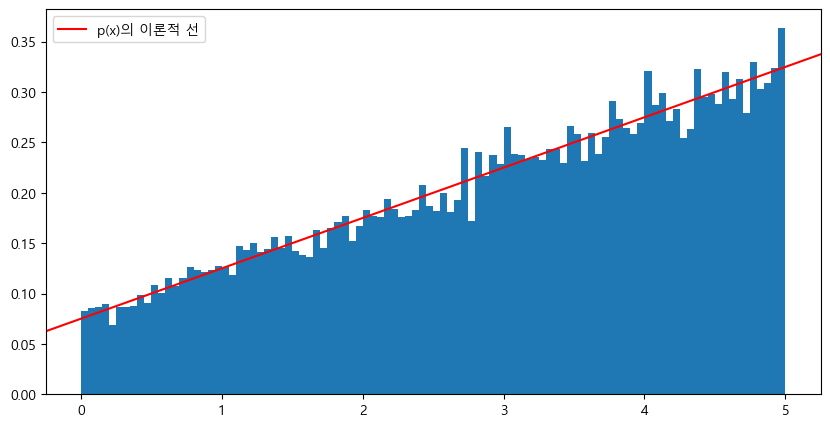

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'  
mpl.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐을 방지하는 파트입니다. 

u = np.random.uniform(size = 20000)
z = 0.5*(-3+np.sqrt(160*u + 9))

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(z, bins=100, density=True)
ax.axline((0, 3/40), slope=1/20, color='r', label='p(x)의 이론적 선')
ax.legend()
plt.show()

어떤가요? 제법 그럴 듯하게 데이터가 나오죠? 저 빨간색 선이 이론적 선인데, 정확히 그것에 부합하게 데이터의 상대적 비율이 구성됩니다. 

그럼 생각해봅시다. 이게 왜 되는 걸까요? 직관적인 설명과 수식에 기반한 논리적인 설명을 둘 다 해보겠습니다. 우선 직관적인 설명을 먼저 해보죠. 우선 아래의 코드를 실행시켜서 그림을 만들어봅시다. 설명을 위해 좀 극단적인 CDF 형태를 가져와봤습니다. 

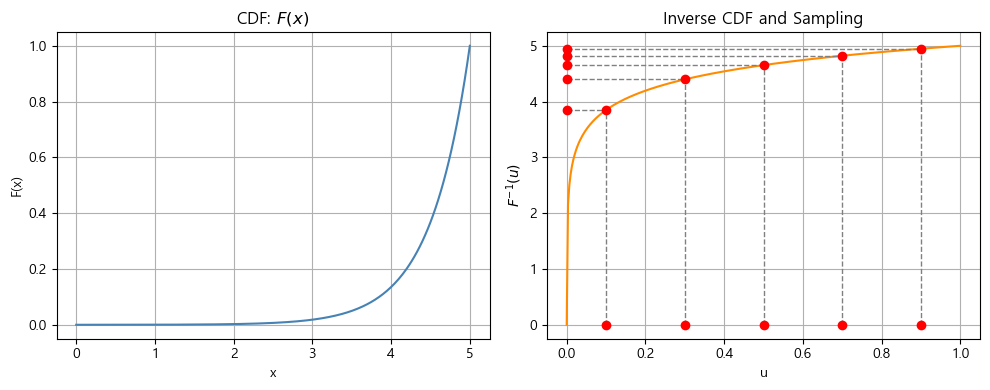

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 함수 정의 ----
a = 2.0
x = np.linspace(0, 5, 300)
F = (np.exp(a*x) - 1) / (np.exp(a*5) - 1)

u = np.linspace(0, 1, 300)
F_inv = (1/a) * np.log(1 + (np.exp(a*5) - 1)*u)

# ---- 균등분포에서 추출된 샘플 (u 값들) ----
u_samples = np.linspace(0.1, 0.9, 5)   # 균등하게 5개 점 (0~1 사이)
x_samples = (1/a) * np.log(1 + (np.exp(a*5) - 1)*u_samples)

# ---- 그림 설정 ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (1) 왼쪽: F(x)
axes[0].plot(x, F, color='steelblue')
axes[0].set_xlabel('x')
axes[0].set_ylabel('F(x)')
axes[0].set_title('CDF: $F(x)$')
axes[0].grid(True)

# (2) 오른쪽: F^{-1}(u)
axes[1].plot(u, F_inv, color='darkorange')
axes[1].set_xlabel('u')
axes[1].set_ylabel(r'$F^{-1}(u)$')
axes[1].set_title('Inverse CDF and Sampling')
axes[1].grid(True)

# ---- 균등표본 시각화 ----
# (x축: 균등분포 표본)
axes[1].scatter(u_samples, np.zeros_like(u_samples), color='red', zorder=5)
# (곡선 위: 매핑된 표본)
axes[1].scatter(u_samples, x_samples, color='red', zorder=5)
# (y축: 최종 샘플 위치)
axes[1].scatter(np.zeros_like(x_samples), x_samples, color='red', zorder=6)

# ---- 점선 연결 ----
for ui, xi in zip(u_samples, x_samples):
    # 수직 점선: u → F^{-1}(u)
    axes[1].plot([ui, ui], [0, xi], color='gray', linestyle='--', linewidth=1)
    # 수평 점선: F^{-1}(u) → y축
    axes[1].plot([0, ui], [xi, xi], color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


좌측의 그림이 하나의 CDF라고 하겠습니다. 0과 5사이의 값을 가지는 확률 변수 X의 값이 커질 수록 CDF의 값이 급격히 증가하네요. 여기서 우리는 어떤 정보를 얻을 수 있나요? 그건 X라는 확률 변수가 5에 가까울 수록 확률이 크다는 점입니다. 즉 작은 값이 나올 가능성은 별로 없고, 5에 가까운 값이 나올 가능성이 매우 큽니다. 그러니까 CDF가 저렇게 나오겠죠. 그러면 이것의 근간이 된 확률 분포를 따르는 데이터를 만들려면, **5 근처에서 많이 만들고, 0에 가까워질 수록 그 빈도를 줄여야 할 것입니다.** 

그런데 inversion method는 그걸 CDF의 역함수를 구하고 거기에 균등 분포의 데이터를 투입해서 해내죠. 왜 그게 되는지, 오른쪽 그림을 보면 이해가 쉽습니다. 오른쪽 그림은 원래 CDF가 그것의 역함수, 즉 y축이 x축이 되고, x축이 y축이 된 상황입니다. 이런 상황에서 균등 분포된 데이터, 예를 들어 0.1, 0.3, 0.5, 0.7, 0.9와 같이 균등한 길이를 가진 가상의 다섯 개의 데이터를 투입한다고 하죠. 오른쪽 그림 x축의 다섯 개의 점이 그것들입니다. 그러면 결과로 뭐가 나오나요? 점선을 따라가보면 5 근처에 몰린 값들이 나옵니다. 그래프의 형태를 보면 당연하죠. 이 함수로 입력값과 출력값을 대응 시킨다고 할 때, 굉장히 넓은 범위의 입력값이 큰 값의 출력값으로 대응되기 때문입니다. 

왜 이런 형태의 그래프가 나온걸까요? 그건 애초에 왼쪽 CDF 그래프에서 x가 큰 구간에서 그래프가 급격히 증가했기 때문입니다. inversion method는 이렇게 구해진 값들이 CDF의 근간이 된 확률 분포 함수를 따르는 데이터로 볼 수 있다고 하는 것입니다. 우리의 직관에 정확히 부합합니다. CDF의 형태로 봤을 때 원래 확률 분포 함수는 값이 커질 수록 확률이 커지는 구조고, 이런 확률 분포를 따르는 데이터를 만들기 위해서는 큰 값이 많이 나오도록 해야 하고, CDF의 역함수를 놓고 x에 균등분포된 값을 넣으면 그래프 형태상 그렇게 출력이 나올 수 밖에 없습니다. 그러니 이런 방법을 써서 구한 데이터들이 원래 확률 분포를 따른다고 할 수 있는거죠  

논리적으로, 수학적으로 설명해보면 어떨까요? 확률 교과서 등에서 아래와 같이 설명합니다. 저는 Blitzstein, J. K., & Hwang, J. (2019). Introduction to probability. Chapman and Hall/CRC. 이 책을 참고했습니다. 

지금 우리가 원하는걸 아주 간명하게 선언하자면, $X=F^{−1}(U)$ 로 정의된 X가 $F(x)$를 따르는 것을 증명하는 것입니다. 즉 어떤 CDF $F(x)$의 역함수에 Unif(0,1)를 따르는 확률 변수 U를 넣어서 만들어진 확률 변수 X가 그 CDF $F(x)$를 따른다는 말이죠. 아래의 수식을 보시죠. 

$$
\begin{aligned}
P(X \le x)
&= P(F^{-1}(U) \le x) \\[6pt]
&= P(U \le F(x)) \\[6pt]
&= F(x)
\end{aligned}
$$

자 어떤가요? 이게 뭔소리인가 싶으실 텐데, 우선 처음의 $P(X \le x)$는 $X=F^{−1}(U)$ 로 정의된 X의 CDF를 선언한 것입니다. 최종적으로 이게 $F(x)$라는 걸 증명하고 싶은거죠. 두번째 수식은 X의 자리에 $F^{−1}(U)$를 대입한 것입니다. 당연히 가능하죠. 그런데 역함수의 성질 때문에 세 번째가 유도됩니다. 부등호 좌우변에 $F(x)$를 적용했다고 봐도 됩니다. 그런데 이러고 보니 $P(U \le F(x))$가 나오는데요, 이건 그냥 $F(x)$로 정리가 됩니다. 왜냐하면, 어떤 값 x까지의 누적 확률이 균등 분포에서 나온 어떤 확률 변수 U보다 클 확률은 정확히 그 누적 확률이거든요. 예를 들어 누적 확률이 0.6이라고 합시다. 0.6이 0과 1사이의 균등 분포에서 나온 불확실한 값 u보다 클 확률이 얼마일까요? 0.6입니다. 0과 1 사이에서 균등하게 나온다고 치면, 열에 여섯 번 정도는 0.6이 더 클테니까요. 그래서 마지막에 $F(x)$로 정리가 되는거죠. 논리적으로는 너무 당연한 전개입니다. 하지만 전 위의 직관적 설명이 더 이해가 쉬운 듯합니다. 제가 이 기법을 공부할 때 스스로 이해하려고 떠올린 설명이거든요.

## 3. Rejection method

Inversion method는 매우 강력한 방법입니다. 직관적이고, 수학적으로 탄탄하고, 효율적이죠. 그런데 아쉽게도 우리가 해결하고자 하는 '확률 분포 함수가 복잡한 상황'에서 바로 쓰기가 어렵습니다. 왜냐하면, 어떤 확률 분포 함수의 CDF는 물론 CDF의 역함수를 늘 쉽게 구할 수 있는게 아니기 때문입니다. 

당장 다변수 함수 상황에서 문제가 생깁니다. 다변수 함수의 역함수를 구하는건 어려운 경우가 많습니다. 예를 들어 소득과 교육 수준을 입력값으로 삼아 기대여명을 출력값으로 주는 함수가 있다고 하죠. 입력 변수가 두개라 다변수 함수라고 할 수 있습니다. 이 함수의 역함수란 기대여명을 입력하면 소득과 교육 수준 값을 제공하는 함수입니다. 그런데, 예를 들어서 소득이 9이고 교육이 10일때에도 기대여명이 60이고, 소득이 10이고 교육이 9일 때에도 기대 여명이 60인 상황이 있다고 하죠. 그러면 역함수에서 60을 입력 받으면 뭘 출력해야 할까요? 소득 9 / 교육 10일까요, 소득 10/ 교육 9일까요. 둘 다 가능하니, 역함수가 함수가 아니게 되는 문제가 생기죠. 하나를 넣으면 여러 개가 대응되니까요. 

요컨대, 다변수 함수의 역함수를 구하는게 어려운 경우가 대부분입니다. 그런데 문제는 확률 분포 함수가 다변수 함수인 경우가 너무 많고, 실무에서는 오히려 일반적이거든요. 왜냐하면 우리는 하나의 확률 변수가 아니라 여러 개의 확률 변수 세트, 즉 벡터의 확률을 알고 싶거든요. 그런데 이 경우에는 아주 특수한 상황이 아닌 한 CDF도 다변수 함수일 공산이 크겠죠. 그리고 여기서 CDF의 역함수를 구하려면 문제가 생깁니다. 하나의 누적 확률로 이어지는 값들의 조합이 여럿일 수 있기 때문입니다. 즉 Inversion method를 쓸 수 없는 상황이 너무 많습니다. 

Rejection method는 이 상황에서 하나의 대안이 될 수 있습니다. Rejection method에 대해서는 그냥 우선 절차를 말씀드리는 것으로 설명을 시작하겠습니다. 절차는 아래와 같습니다. 

1. p(x)가 내가 분포의 양상을 확인하고 싶은 확률 분포 함수
2. g(x)라는 임의의 분포 함수를 상정. 해당 분포 함수는 샘플링이 쉽고, m*g(x)는 모든 구간에서 f(x)보다 커야 함
3. g(x)에서 샘플링 -> z
4. R이라는 비율을 계산 $R = \frac{f(z)}{m \times g(z)}$
5. U(0,1)에서 샘플링 -> u 
6. 만약 R > u라면, z를 p(x)에서 나왔다고 가정, 그렇지 않다면, 3으로 돌아감


간단하긴 한데, 가만 살펴보면 희한합니다. p(x)를 따르는 데이터를 얻기 위해 g(x)라는 듣도 보도 못한걸 가져옵니다. 이걸 envelop function, 감싸는 함수, 라고 부릅니다. $m \times g(x)$가 모든 구간에서 커야 한다는 조건 때문에 나온거죠. 모든 구간에서 관심 함수인 p(x)를 덮어 감싸고 있어야 합니다. 이 미지의 g(x)로부터 값을 하나 뽑아냅니다. 아시다시피 p(x)랑은 하등 관계가 없는 값입니다. 그런 다음 R이라는 이상한 값을 계산합니다. 5번 6번 절차는 사실 R이라는 값을 채택율로 삼는 것인데, g(x)에서 나온 값인 z를 p(x)에서 나왔다고 치기 위한 절차입니다. 즉 채택율이 0.7이면, 왠만하면 그 값이 p(x)에서 왔다고 판단하는거죠. 

다소 어이가 없습니다. g(x)에서 왔는데, p(x)에서 왔다고 치겠다는 겁니다. R로 주어진 채택율에 따라 드문드문 그렇게 여기긴 하지만요. 그런데 놀랍게도, 이게 작동합니다. 아래의 코드를 실행시켜 봅시다. 위에서 inversion method에서 다뤘던 함수를 그대로 활용한 것입니다. 

20058
10000


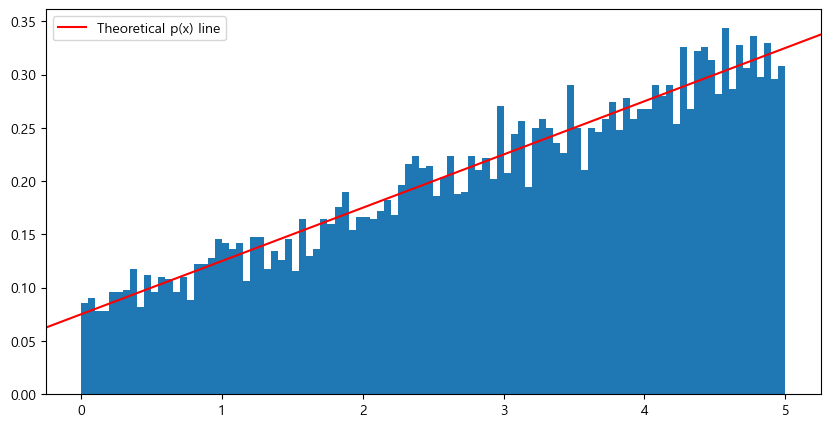

In [3]:
count = 0
k = 0
sample = np.empty(10000)


while k < 10000:
    z = np.random.uniform(0, 5)
    r = ((1/40)*(2*z+3))/(2*0.2)
    if r > np.random.uniform(0,1,1):
        sample[k] = z
        k += 1
    count += 1

print(count)
print(len(sample))

fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot(1,1,1)
ax.hist(sample, bins = 100, density = True)
ax.axline((0, 3/40), slope=1/20, color = 'r', label='Theoretical p(x) line')
ax.legend()
plt.show()

코드는 간단합니다. 위에서 말한 것을 그대로 구현한 것입니다. envelop function으로 균등 분포 함수를 썼습니다. $m \times g(x)$가 모든 구간에서 다 포괄하려고 m을 2로 삼아 곱한 것입니다. 그래서 2곱하기 0.2 (0과 5사이의 균등 분포 함수) 가 나오는거죠. 그런데 놀랍게도 결과가 잘 나옵니다. 그럼 우리가 생각해봐야 하는건 '왜 이게 되는가?'입니다. 사실 매우 간단한 원리입니다. 아래의 코드를 실행시켜 그림을 그려봅시다. 

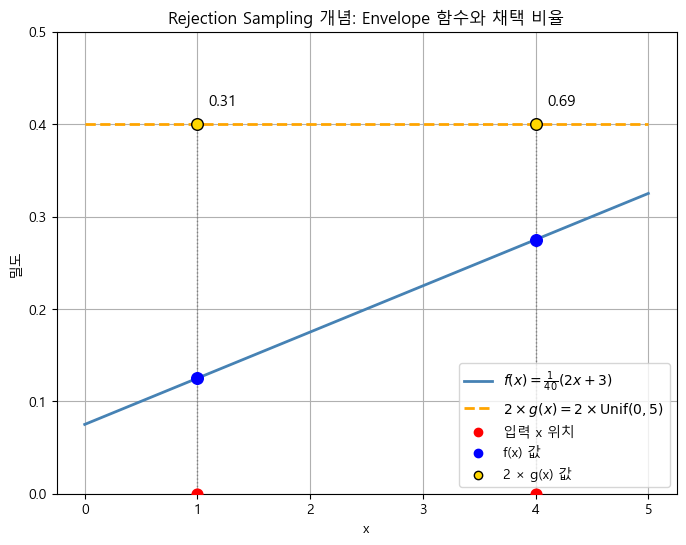

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# ---- 함수 정의 ----
x = np.linspace(0, 5, 300)
f = (1/40)*(2*x + 3)       # target density
g = np.full_like(x, 1/5)   # proposal: Uniform(0,5)
M = 2                      # envelope multiplier
Mg = M * g                 # envelope function

# ---- 특정 지점 선택 ----
x_points = [1, 4]
f_points = (1/40)*(2*np.array(x_points) + 3)
g_points = np.full_like(f_points, 1/5)
Mg_points = M * g_points
ratio = f_points / Mg_points

# ---- 그림 ----
plt.figure(figsize=(8,6))
plt.plot(x, f, label=r'$f(x) = \frac{1}{40}(2x+3)$', color='steelblue', linewidth=2)
plt.plot(x, Mg, '--', label=r'$2 \times g(x) = 2 \times \mathrm{Unif}(0,5)$', color='orange', linewidth=2)

# ---- 각 지점 시각화 ----
for xi, fi, gi, mgi, ri in zip(x_points, f_points, g_points, Mg_points, ratio):
    # x축의 빨간 점
    plt.scatter([xi], [0], color='red', s=60, zorder=5)
    # 수직 점선
    plt.vlines(xi, 0, mgi, color='gray', linestyle=':', linewidth=1)
    # f(x), 2g(x) 점 표시
    plt.scatter([xi], [fi], color='blue', s=70, zorder=6)
    plt.scatter([xi], [mgi], color='gold', edgecolor='k', s=70, zorder=6)
    # 비율 텍스트 (채택 확률)
    plt.text(xi+0.1, mgi+0.02, f"{ri:.2f}", color='black', fontsize=11)

# ---- 범례용 더미 점 ----
plt.scatter([], [], color='red', label='입력 x 위치')
plt.scatter([], [], color='blue', label='f(x) 값')
plt.scatter([], [], color='gold', edgecolor='k', label='2 × g(x) 값')

plt.xlabel('x')
plt.ylabel('밀도')
plt.title('Rejection Sampling 개념: Envelope 함수와 채택 비율')
plt.legend()
plt.grid(True)
plt.ylim(0, 0.5)
plt.show()


지금 위의 코드 상황을 그려보면 이 그림과 같습니다. p(x), 이 경우는 연속 확률 변수이니 그걸 반영해서 f(x)가 있다고 합시다. 그런데 그걸 g(x)라는 envelop function을 두 배해서 덮은거죠. 그런 다음에 g(x), 즉 0과 5 사이의 균등 분포에서 데이터를 만들어냅니다. 그런데 그러면 아마 우리의 관심 분포 f(x)와 달리 전 구간에 균등하게 값이 나올겁니다. 

그런데 여기서 rejection method의 핵심이 들어옵니다. 그걸 다 그냥 받아들이는게 아니라, 매번 R값을 계산합니다. 그 R은 $m \times g(z)$와 f(z)의 비율이죠. 예를 들어 z가 1이라고 합시다. 아래쪽 첫 번째 빨간점입니다. 그러면 f(z)의 값은 그 위의 파란점이고 $m \times g(z)$는 노란점이 됩니다. 그 둘의 비율이 얼마인가요? 이 경우에는 0.31입니다. 그런데 4에서는 딱 봐도 비율이 더 크죠. f(z)가 더 많이 올라와 있고, envelop function은 수평선이니까요. 그래서 0.69가 나옵니다. 

이 두 수치, 0.31과 0.69를 채택율 (acceptance rate)로 삼으면 어떤 일이 생길까요? 4는 채택할 개연성이 크고, 1은 그렇지 않습니다. 그러면 g(x)에서 값이 마구 생겨도, 결국 큰 값 위주로 채택이 됩니다. 그리고 그게 바로 정확히 우리가 원하는 일입니다. 확률 분포 함수가 저렇게 생겼으면 값이 커질 수록 더 많은 값이 나오도록 해야 합니다. 그런데 값이 커질 수록 R, 채택율이 커집니다. 그러면 균등 분포에서 나왔다고 하더라도, 결국 살아남아 데이터로 채택되는 것은 큰 값 위주일 것입니다. 그러니까 g(x)에서 나왔지만 채택율을 통과해서 살아남은 데이터는 f(x)에서 나왔다고 볼 수 있게 되는거죠. 이게 바로 rejection method가 작동하는 이유입니다. 

기똥찬 면이 있습니다만, 이것도 한계가 있습니다. envelop function을 잘 구하기가 쉽지 않기 때문입니다. 정확히 말하자면, 쓸만하고 효율적인 envelop function을 구하는게 쉽지 않습니다. 위의 구현 코드에서 나왔듯이, 이 방법의 핵심은 이렇습니다. 

1. 샘플링이 쉬운 엉뚱한 분포 g(x)에서 값을 만들고,
2. R값에 근거해서 일부는 버리고 일부는 채택하는 것입니다.

그래서 약점이 분명합니다. 버리는 값이 많을 수록 데이터를 만드는데 시간이 많이 걸립니다. 비효율적이라는 말입니다. 그럼 언제 많이 버리게 될까요? 전반적으로 R, acceptance rate이 낮을 때 그렇습니다. 그래서 효율적이려면, envelop function에 적당한 상수를 곱한 것이 f(x)를 간신히 덮는 꼴이 되어야 합니다. 그래야 전반적으로 acceptance rate이 올라갈 것이니까요. 그런데, **문제는 애초에 이런걸 하는 이유가 f(x)를 잘 몰라서 하는거라는 겁니다.** 그렇게 f(x)에 대해서 잘 알아서 간신히 덮는 함수도 쉽게 제안할 수 있을 정도면, 그냥 f(x)에서 정보를 뽑고 말지, 굳이 샘플링 기법을 쓸 필요가 없습니다. 그래서 보통 envelop function이 관심 확률 분포를 감싸는 걸 보장하기 위해 envelop function에 아주 큰 값을 곱할 수 밖에 없습니다. 그러면 자연히 버리는 값이 엄청 많아질 것입니다. 전 구간에서 채택율이 낮아질 것이기 때문입니다. 즉 비효율적이기 쉽죠. 

어떻게 하면 좋을까요? Inversion method는 수학적으로 명료한데, 실질적으로 쓰기 어렵습니다. Rejection method는 여러 상황에 대응이 가능한데, 비효율적이기 쉽고 이는 실무적으로 큰 문제입니다. 시간은 소중하고, 장기적으로 우리는 다 죽으니까요^^ 현대적인 샘플링 기법은 이런 기초적인 기법을 융합/개선/재조정하여 새로운 지평을 엽니다. 이제 그걸 알아봅시다. 

## 4. Gibbs sampling

이제 드디로 현대적인 기법으로 들어가게 되네요. 베이지안 통계에서 현대적인 샘플링 기법의 주류는 소위 MCMC (Markov Chain Monte Carlo) 라 불리는 계열의 기법이 차지하고 있습니다. 가장 많이 사용되고 있다고 해도 과언이 아닙니다. 그리고 MCMC 안에 크게 두 가지 계열이 존재한다고 정리할 수 있는데, Gibbs sampling과 MH(Metropolis-Hastings) 알고리즘이 그것입니다. 우리는 그 중 먼저 Gibbs sampling에 대해서 알아보겠습니다. 실제 LDA 구현에 활용되기도 하는 샘플링 기법입니다. 

Gibbs 샘플링은 과거 물리학자 Gibbs가 제안한 분포에서 아이디어를 얻은 샘플링 기법이라 이렇게 불립니다. J. Willard Gibbs라는 19세기에 주로 활동했던 물리학자가 Gibbs 분포라는 것을 제안하였습니다. 어떤 시스템이 가지는 에너지 상태의 분포를 표현하기 위해 그걸 썼다네요. 에너지 상태가 고정된 값을 가지는게 아니라 확률 분포를 가지고 존재한다고 생각한 것입니다. 그러면 그 확률 분포를 반영하여 가능한 상태를 확률적으로 뽑아보는 일이 필요하죠. 여기서 확률 분포에서 데이터를 샘플링하는 시도가 생기고, 거기서 생긴 노하우가 일반적인 다변수 확률 분포에서 데이터를 샘플링하는 것으로 확장된 것입니다. 그리고 그게 Gibbs 샘플링이라 불리기 시작한 것이지요. 

아이디어의 핵심은 간단합니다. 복잡한 다변수 확률 분포가 있다고 합시다. 베이지안 통계에서는 사후 분포에서 자주 이런 일이 생기지요. 앞서 말했듯, 이런 상황에서 inversion method도, rejection method도 쓰기 어렵습니다. 깁스 샘플링은 각 변수의 완전 조건부 분포 (full conditional distribution)을 유도하여 그것에서 샘플링을 하는 것으로 이 상황을 극복합니다. 예를 들어 세 개의 변수로 이루어진 확률 분포가 있다고 하죠. 변수를 a,b,c라고 하겠습니다. 그러면 우리가 샘플링을 하고 싶은 분포는 $p(a,b,c)$가 됩니다. 깁스 샘플링의 전략은 간단합니다. a,b,c의 초기값을 줍니다. 그걸 $a^{(0)},b^{(0)},c^{(0)}$이라고 하겠습니다. 이 값들을 벡터로 본다면, $[a^{(0)},b^{(0)},c^{(0)}]$라는 벡터로 이해해도 됩니다. 그런 다음 아래를 반복하는 것입니다. 

$$
\begin{aligned}
a^{(t+1)} &\sim p(a|b^{(t)},c^{(t)})\\
b^{(t+1)} &\sim p(b|a^{(t+1)},c^{(t)})\\
c^{(t+1)} &\sim p(c|b^{(t+1)},a^{(t+1)})
\end{aligned}
$$

두 가지 의문이 생깁니다. 1) 저게 왜 쉽다는건가? 2) 저게 왜 되는가? 

먼저 이렇게 하면 왜 상황이 좋아지는지 부터 살펴봅시다. 일단 완전 조건부 분포가 되면 해당 확률 분포 함수가 단변수 함수가 됩니다. 나머지 변수들이 상수로 취급되어 함수가 단순해지는 것입니다. 즉 $p(a,b,c)$에 비해 $p(a|b,c), p(b|a,c), p(c|a,b)$ 는 무척 단순합니다. 그러면 여기서 inversion method도, rejection method도 쓰기가 훨씬 편해집니다. 즉 원래 복잡한 함수가 단순한 함수가 되어서 단순한 함수에 적용할 수 있는 기본적인 샘플링 기법을 적용하기가 좋아진다는 말입니다. 깁스 샘플링은 그렇게 단순화된 조건부 분포로부터 반복적으로 값을 얻어내면 그게 원 분포를 따르는 데이터가 된다고 하니, 상황이 개선되는 셈이지요. 요컨대 복잡한 분포를 단순한 분포로 만들어서 샘플링을 하겠다는 전략이라 쉬워지는 것입니다. 

두 번째로 저게 왜 되는건가, 즉 저렇게 하면 목표 분포인 P(a,b,c)를 표현하는 데이터가 왜 만들어지는가는, 증명의 영역이라 여기서 길게 다루기가 어렵습니다. 대략적으로 구도만 설명드리자면, 이는 마르코프 체인과 관련이 있습니다. 마르코프 체인이 특정한 조건을 갖추면, 그것이 안정적인 균형 상태를 이루게 됩니다. 그리고 깁스 샘플링은 바로 그런 안정적인 균형을 달성할 수 있는 마르코프 체인 구도를 충족합니다. 그래서 깁스 샘플링이 되는 거죠. 자세한 사항은 관련 교과서를 참조하세요. 

그러면 일단 간단한 예를 가지고 깁스 샘플링 실습을 해봅시다. 맨 서두에 이야기했던 Lynch, S. M.의 책에 나온 사례입니다. 아래와 같은 확률 분포가 있다고 하고, 그것으로부터 데이터를 샘플링하고 싶다고 해봅시다. 

$$
\begin{aligned}
p(x,y) = \frac{1}{28}(2x+3y+2), \quad 0<x<2, 0<y<2
\end{aligned}
$$

그리 복잡하지는 않습니다. 그냥 3차원에 존재하는 평면 형태의 확률 분포 함수입니다. 다만 다변수 함수라 inversion method를 쓸 수 없죠. 형태가 간단하여 조금 익숙하신 분이라면 효율적인 rejection method용 envelop function은 찾으실 수 있겠지만, 못한다고 가정하고 해보겠습니다^^ 뭘 하면 될까요? x와 y의 입장에서 full conditional distribution을 구해야 합니다. 즉 p(x|y)와 p(y|x)를 구한다는 말이죠. 그걸 어떻게 구할까요? 그건 $p(a|b) = \frac{p(a,b)}{p(b)}$의 공식과 $p(b) = \int_{a}p(a,b)da$라는 공식을 활용하면 됩니다. 적용해보면 아래와 같죠. 

$$
\begin{gathered}
p(y) = \int_{x}p(x,y)dx = \int_{0}^2 \frac{1}{28}(2x+3y+2)dx = \frac{1}{28}(6y+8)\\[15pt]
p(x) = \int_{y}p(x,y)dy = \int_{0}^2 \frac{1}{28}(2x+3y+2)dy = \frac{1}{28}(4x+10)\\[15pt]
p(x|y) = \frac{p(x,y)}{p(y)} = \frac{2x+3y+2}{6y+8}\\[15pt]
p(y|x) = \frac{p(x,y)}{p(x)} = \frac{2x+3y+2}{4x+10}
\end{gathered}
$$

자 이렇게 한 후 x와 y에 초기값을 주고, 각 조건부 분포에서 조건으로 주어진 x와 y에 실제 샘플링된 값을 넣고 단변수 분포 함수로부터 데이터를 한 번씩 샘플링하는 것입니다. 이를 위해 inversion method를 쓴다고 해보죠. 그러면 각 조건부 분포 함수의 CDF를 구하고 그것의 역함수를 구하는 과정이 추가적으로 필요합니다. 아래와 같은 식으로 진행하면 되죠. 

$$
\begin{aligned}
\text{p(x|y)의 CDF} &= \int^z_0 p(x|y)dx \\[15pt]
&= \int^z_0 \frac{2x+3y+2}{6y+8}dx \\[15pt]
&= \frac{z^2+(3y+2)z}{6y+8} \\[15pt]
\end{aligned}
$$

그리고 이것의 역함수를 구합니다. 

$$
\begin{aligned}
\frac{z^2+(3y+2)z}{6y+8} &= u \\[15pt]
z^2+(3y+2)z-(6y+8)u &= 0 \\[15pt]
\frac{-3y-2+\sqrt{(3y+2)^2+4(6y+8)u}}{2} &= z
\end{aligned}
$$

근의 공식을 써서 정리한 것입니다. 

p(y|x)도 마찬가지로 정리할 수 있습니다. 위와 같은 요령으로 진행합니다. 

$$
\begin{aligned}
\text{p(y|x)의 CDF} &= \int^k_0 p(y|x)dy \\[15pt]
&= \int^k_0 \frac{2x+3y+2}{4x+10}dy \\[15pt]
&= \frac{1.5k^2+(2x+2)k}{4x+10} \\[15pt]
\end{aligned}
$$

그리고 이것의 역함수를 구합니다. 

$$
\begin{aligned}
\frac{1.5k^2+(2x+2)k}{4x+10} &= u \\[15pt]
1.5k^2+(2x+2)k-(4x+10)u &= 0 \\[15pt]
3k^2+(4x+4)k-(8x+20)u &= 0 \\[15pt]
\frac{-4x-4+\sqrt{(4x+4)^2+12(8x+20)u}}{6} &= k
\end{aligned}
$$

자 이제 드디어 Gibbs sampling을 inversion method를 활용해서 진행할 준비가 되었습니다. 즉 $p(x|y)$와 $p(y|x)$를 구했고, 거기서 샘플링을 하기 위한 각 확률 분포 함수의 CDF의 역함수를 유도했습니다. 그러면 앞에 설명한 절차를 반영하여 다음과 같이 작업을 진행합니다. 

1. x와 y에 각각 초기값을 입력한다. 이것이 $x^{(0)}, y^{(0)}$이 된다
2. t=0으로 설정한다. 
3. x를 샘플링한다. $x^{(t+1)} \sim p(x|y^{(t)})$
4. y를 샘플링한다. $y^{(t+1)} \sim p(y|x^{(t+1)})$
5. t = t+1이 되고 3으로 돌아간다 
    - t가 특정 조건이 되면, 즉 일정 부분 데이터가 산출되면 3으로 돌아가는 것을 중지한다
    
아래는 이 절차를 코드로 구현하고 그것을 시각화한 것입니다. 

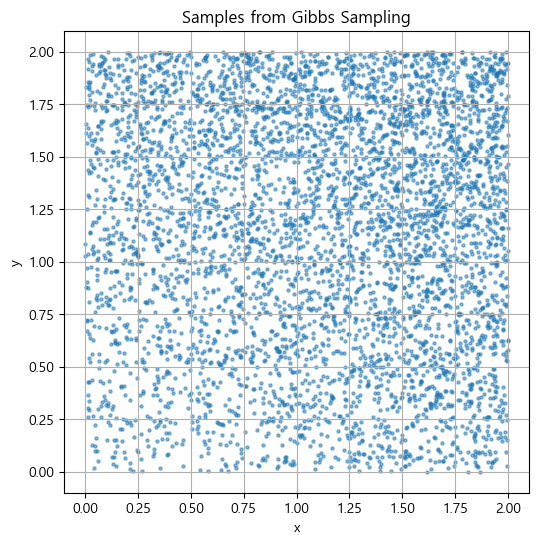

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 반복 횟수
N = 5000

# 샘플을 저장할 배열
x = np.zeros(N)
y = np.zeros(N)

# 초기값
x[0] = 1.0
y[0] = 1.0

# Gibbs sampling 반복
for t in range(0, N-1):
    # ---- 1. x | y ----
    U1 = np.random.rand()
    x[t+1] = (-(3*y[t] + 2) + np.sqrt((3*y[t] + 2)**2 + 4*(6*y[t] + 8)*U1)) / 2

    # ---- 2. y | x ----
    U2 = np.random.rand()
    y[t+1] = (-(4*x[t+1] + 4) + np.sqrt((4*x[t+1] + 4)**2 + 12*(8*x[t+1] + 20)*U2)) / 6

# 결과 시각화
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=5, alpha=0.5)
plt.title("Samples from Gibbs Sampling")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


잘 되죠? 우상단으로 갈 수록 평면의 높이가 올라가고, 그건 거기서 확률이 높다는 뜻인데, 실제로 데이터가 그렇게 나오고 있습니다. 실제 적용에서는 burn-in period를 적용하는 경우도 있습니다. 초기 데이터는 안정적으로 목표 분포를 따른다고 보기 어렵다고 보고 버리는거죠. 예를 들어 위에서 5000쌍을 뽑았는데, 맨 처음 1000쌍 정도는 버리는 것입니다. 아래는 좀 더 예쁜 그림입니다.

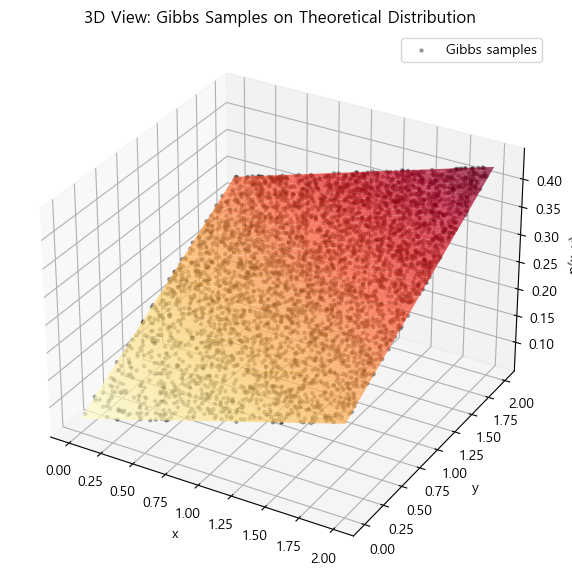

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 도화지

# ---- Gibbs 샘플링 (이전 코드 그대로) ----
N = 5000
np.random.seed(42)
x = np.zeros(N)
y = np.zeros(N)
x[0], y[0] = 1.0, 1.0

for t in range(N - 1):
    U1 = np.random.rand()
    x[t+1] = (-(3*y[t] + 2) + np.sqrt((3*y[t] + 2)**2 + 4*(6*y[t] + 8)*U1)) / 2
    x[t+1] = np.clip(x[t+1], 0, 2)

    U2 = np.random.rand()
    y[t+1] = (-(4*x[t+1] + 4) + np.sqrt((4*x[t+1] + 4)**2 + 12*(8*x[t+1] + 20)*U2)) / 6
    y[t+1] = np.clip(y[t+1], 0, 2)

# ---- 3D Surface Plot ----
xx, yy = np.meshgrid(np.linspace(0, 2, 80), np.linspace(0, 2, 80))
f = (1/28)*(2*xx + 3*yy + 2)  # 이론적 joint pdf

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# 이론적 확률 분포 곡면
ax.plot_surface(xx, yy, f, cmap='YlOrRd', alpha=0.7, linewidth=0)

# Gibbs 샘플 포인트
f_samples = (1/28)*(2*x + 3*y + 2)
ax.scatter(x[1000:], y[1000:], f_samples[1000:], color='black', s=5, alpha=0.3, label='Gibbs samples')

ax.set_title("3D View: Gibbs Samples on Theoretical Distribution")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("p(x, y)")
ax.legend()
plt.show()


## 5. MH 알고리즘

샘플링 기법 중 마지막으로 Metropolis Hastings algorithm에 대해서 알아보겠습니다. 짐작하시다시피, Metropolis도 Hastings도 사람 이름입니다. Nicholas Metropolis 라는 물리학자와 W.K.Hastings라는 통계학자의 이름을 딴 것이지요. 먼저 Metropolis가 동료들과 1953년에 쓴 논문이 이 기법의 시작이 됩니다. 이 분이 특정 온도에서 입자 상태를 시뮬레이션을 통해 추정하는 방법을 처음 제안했다고 하네요. 그때 확률적으로 상태를 이동시켜가며 에너지 분포를 근사하는 방법을 도입했는데, 그게 이후 샘플링 기법으로 발전한 것입니다. 그리고 그걸 1970년에 Hastings가 제안 함수가 비대칭적이어도 상관없는 형태로 일반화 했습니다. 그래서 오늘날의 MH 알고리즘이 만들어졌죠. 이후 Gibbs 샘플링 또한 이 MH 알고리즘의 특수한 형태임을 지적하는 논의가 나오기도 했습니다. 따로 발전되어 왔지만, 개념적으로는 하나의 계통에 있음이 확인된 것이지요. 

그럼 이건 또 어떻게 하는걸까요? 먼저 추상적으로 표현해보면 이렇습니다. 목표 분포가 $p(x)$라고 하겠습니다. 아시다시피 이건 '복잡한 분포'로 잡혀 있습니다. 샘플링이 어렵다는 말입니다. 그래서 rejection method 처럼 후보를 제안하는 분포를 가정합니다. 그걸 제안 분포라고 부르고, $q(x'|x)$라고 하겠습니다. 현재 값을 기반으로 다음 후보값을 제안하는 형태이기에 이렇게 조건부 함수로 표현합니다. 앞서 rejection method에서는 이런 제안하는 함수에 상수를 곱하면 $p(x)$를 덮어야 했는데, 그런 조건이 필요 없습니다. 그냥 샘플링하기 쉬운 분포면 됩니다. 이걸 가지고 아래처럼 진행합니다. 

1. 초기값을 설정합니다. 그걸 $x^{(0)}$이라고 하겠습니다. 
2. x의 다음 시점 값이 필요합니다. 이를 위한 후보값을 만들겠습니다. $q(x'|x)$를 활용해서 샘플링합니다. 그 후보를 x' 라고 하겠습니다. 
    1. $x' \sim q(x'|x)$ 입니다. 즉 현재값을 조건으로 삼은 상태에서 후보값을 제안함수를 활용해 뽑습니다. 
3. 후보값을 p(x)에서 나온 값을 볼지 그렇지 않을지 acceptance probability, 채택 확률을 계산합니다. 아래와 같이 계산됩니다. 
    1. $a(x,x') = min(1,\frac{p(x')q(x|x')}{p(x)q(x'|x)})$
4. a(x,x')를 채택확률로 삼아서 x'을 받아들일지 그렇지 않을지 판단합니다. 
    1. Uniform(0,1)에서 u를 하나 뽑아서, $u<a(x,x')$이면 $x^{(t+1)} = x'$이 되고, $u>=a(x,x')$ 이면 $x^{(t+1)} = x^{(t)}$입니다. 
5. 2-4를 충분히 많이 반복합니다. 

즉 1. 초기값 설정, 2. 후보값 제안, 3. 채택 확률 계산, 4. 채택 혹은 거절 (거절의 경우 기존값 반복), 5. 2-4를 반복으로 이루어진 구조입니다. 

이게 왜 되는걸까요? 사실 원리는 간단합니다. 제안 함수가 제안한 새로운 후보값이 있다고 하겠습니다. 그 후보값이 목표 분포에서 가지는 확률이 있을 것입니다 (정확히는 확률 밀도, 즉 density라고 봐야하는데, 설명을 위해 그냥 확률이라 하겠습니다). 그 새로운 후보값이 목표 분포에서 가지는 확률이 기존값이 목표 분포에서 가지는 확률에 비해 큰지 작은지, 작다면 얼마나 작은지 보고 채택 확률을 결정합니다. 기존 확률에 비해 크거나 작아도 미세하게 작으면 채택 확률을 높게 가져가고, 기존 값의 확률에 비해 아주 작으면 채택 확률을 낮게 가져가는거죠. **즉 '새로운 후보값이 기존 값에 비해 그럴 듯하고 자주 나올 수 있는 값이면 채택하고, 그렇지 않으면 채택하지 않는다'는 것이 핵심입니다.** 이렇게 되면, 결국 목표 분포에서 높은 값을 가지는 값들이 많이 모이고, 그렇지 않은 값들은 적게 모입니다. 그건 목표 분포를 따르는 데이터라고 할 수 있게 됩니다. 

약간 애매하게 느껴지실텐데, 제안함수가 대칭함수라고 가정해봅시다. 즉 $q(x|x') = q(x'|x)$인 q(x)를 가정하는거죠. 그렇게 되면 채택율 계산이 $min(1,\frac{p(x')}{p(x)})$ 이렇게 간단해집니다. 그러면 더 감이 오실겁니다. x'이 기존 값인 x에 비해 목표 분포에서 가지는 확률값의 비율이 채택율이 되는거죠. 실제 Metropolis가 1953년에 처음 제안한 형태는 이처럼 대칭 함수를 제안함수로 삼은 방식이었다고 합니다. 

사실 저는 처음에 q(x'|x)이 뭔가 싶었습니다. 이건, 기존값을 조건으로 삼겠다는건데, 주로 기존값을 q(x'|x)의 형태를 결정하는 파라미터로 삼는 방식으로 구현됩니다. 예를 들어 q(x'|x)가 정규분포함수라고 하죠. 아시다시피 정규 분포 함수는 두 개의 파라미터가 필요합니다. 평균과 분산이 그것입니다. 그 중에서 평균값을 현재의 x값, 즉 $x^{(t)}$로 삼는 것입니다. 분산은 임의로 설정해두고요. 그러면 이런 말이 됩니다. 현재 값이 5라고 합시다. 그러면 5를 평균으로 삼은 어떤 정규분포로부터 후보값을 뽑습니다 (분산은 임의로 4정도라고 하죠. 이게 커지면 후보값을 내놓는 범위가 넓어집니다. 탐색범위가 넓어진다고도 할 수 있겠네요). 그 후보값이 목표 분포에서 얼마나 말이 되는지, 그 정도가 기존값인 5에 비해 어떠한지 살펴본 후, 그걸 채택할지 그렇지 않을지 보는거죠. 저는 그래서 이렇게 이미지하고 있습니다. 현재값의 위치에서 근처의 후보값을 찾아낸 후 그것의 개연성에 근거하여 채택 및 거절하고, 계속해서 움직인다. 이렇게요. 

이제 채택 확률을 공식적으로는 $a(x,x') = min(1,\frac{p(x')q(x|x')}{p(x)q(x'|x)})$ 이렇게 계산하는 것도 쉽게 이해하실 수 있을 것입니다. q(x'|x)는 기존 값의 자리에서 새로운 값을 제안하는 일을 합니다. 그런데 이 제안함수가 위에서 가정한 것처럼 대칭적이지 않고 비대칭적이라면 어떨까요. 즉, 체계적으로 어느 한쪽으로 치우친 값을 주는 경향이 있다면 어떨까요? 그러면 아무래도 치우친 쪽으로 데이터가 많이 만들어질텐데, 그러면 p(x)를 따르는 데이터를 만든다는 목적을 저해하게 됩니다. q(x'|x)의 경향이 거기에 반영되니까요. 그래서 비대칭적일 경우 그것을 보정하는 파트를 만들어 둔 거죠. 그게 $\frac{q(x|x')}{q(x'|x)}$ 입니다. 

직관적으로 이해해보면 이런거죠. 예를 들어 x가 주어졌을 때 x'이 나올 확률이 x'이 주어졌을 때 x가 나올 확률보다 크다면, 그것은 q(x'|x)가 x'을 만들어내는 불균형한 경향이 있다는 말이죠. 즉 가만 놔두면 x'을 더 많이 만든다는 것입니다. 그러면 p(x')과 p(x)의 비율만 고려하지 않고, 거기에 일종의 패널티를 주는 것입니다. 그 상황에서는 $\frac{q(x|x')}{q(x'|x)}$가 1보다 당연히 작을테니, $\frac{p(x')}{p(x)}$가 작아지는 효과가 나겠지요. 즉 이건 'q(x'|x)가 애초에 x'을 추출할 불균형한 경향을 갖고 있으니, 의도적으로 $\frac{p(x')}{p(x)}$로 계산되는 채택 확률을 낮춰주자'라는 설계인 셈입니다. 거꾸로도 마찬가지입니다. 만약 x'가 q(x'|x)의 경향상 좀처럼 나올 수 없는 값이었다면, 그건 $\frac{p(x')}{p(x)}$로 계산되는 채택 확률을 비례해서 올려주는 것이지요. Hastings는 이런 보정항을 통해 제안함수를 뭐든 쓸 수 있게 만들어 준 셈입니다. 그리고 이걸 마르코프 체인의 용어로 설명하면, 이를 통해 detailed balance, 즉 상세균형이라는 조건이 만족되면서 장기적으로 목표 분포로 수렴하게 되는 것이지요. 

그럼 이제 또 실습을 해봅시다. 앞서 나온 목표 분포를 그대로 활용하겠습니다. 

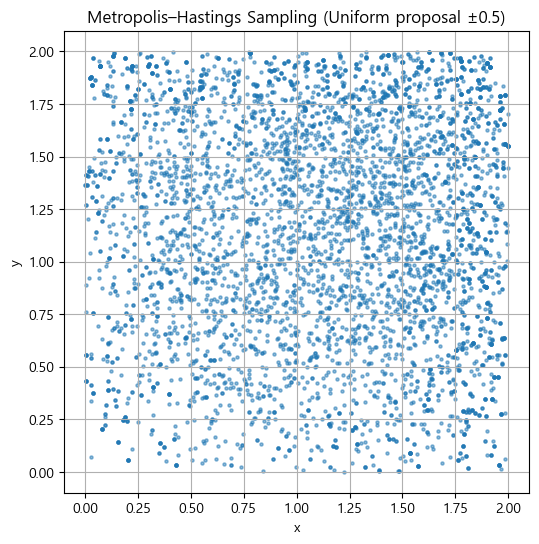

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 타깃 분포 (정규화 상수는 무시해도 됨)
def p_xy(x, y):
    if 0 < x < 2 and 0 < y < 2:
        return (2*x + 3*y + 2)
    else:
        return 0

# 반복 횟수
N = 5000

# 샘플을 저장할 배열
samples = np.zeros((N, 2))

# 초기값
samples[0] = [1.0, 1.0]

# MH 반복
for t in range(N-1):
    x_curr, y_curr = samples[t]

    # --- 제안분포: U(x-0.5, x+0.5) ---
    x_prop = np.random.uniform(x_curr - 0.5, x_curr + 0.5)
    y_prop = np.random.uniform(y_curr - 0.5, y_curr + 0.5)

    # 타깃 분포 비율 (제안분포 대칭이므로 q항 생략)
    p_curr = p_xy(x_curr, y_curr)
    p_prop = p_xy(x_prop, y_prop)

    alpha = min(1, p_prop / p_curr) if p_curr > 0 else 1 #방어적 조건문임

    # 채택/거절
    if np.random.rand() < alpha:
        samples[t+1] = [x_prop, y_prop]  # accept
    else:
        samples[t+1] = [x_curr, y_curr]  # reject (stay)

# 결과 시각화
plt.figure(figsize=(6,6))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.5)
plt.title("Metropolis–Hastings Sampling (Uniform proposal ±0.5)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


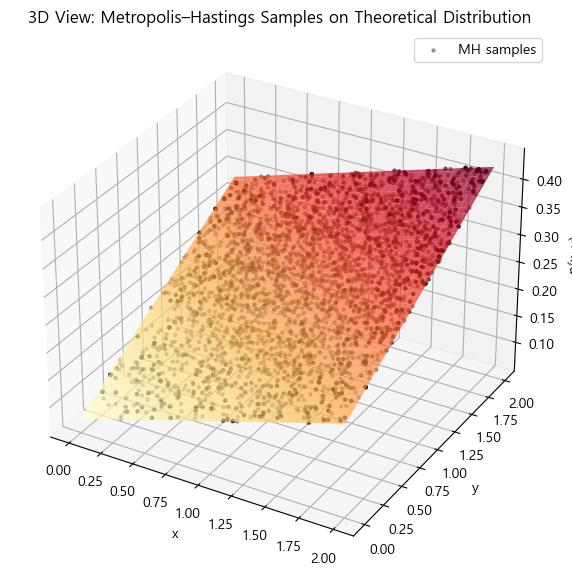

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 도화지

# ---- 목표 분포 정의 ----
def p(x, y):
    mask = (x > 0) & (x < 2) & (y > 0) & (y < 2)
    val = np.zeros_like(x)
    val[mask] = (1/28) * (2*x[mask] + 3*y[mask] + 2)
    return val

# ---- Metropolis–Hastings 샘플링 ----
N = 5000
np.random.seed(42)
x = np.zeros(N)
y = np.zeros(N)
x[0], y[0] = 1.0, 1.0

proposal_width = 0.5  # 제안 범위 ±0.5

for t in range(1, N):
    # 후보 제안 (균등 분포)
    x_prop = np.random.uniform(x[t-1] - proposal_width, x[t-1] + proposal_width)
    y_prop = np.random.uniform(y[t-1] - proposal_width, y[t-1] + proposal_width)
    
    # 목표 분포에서의 확률 계산
    p_curr = p(np.array([x[t-1]]), np.array([y[t-1]]))
    p_prop = p(np.array([x_prop]), np.array([y_prop]))
    
    # 채택 확률
    alpha = min(1, p_prop / p_curr) if p_curr > 0 else 1
    
    # 수용/거절 결정
    if np.random.rand() < alpha:
        x[t], y[t] = x_prop, y_prop  # 수용
    else:
        x[t], y[t] = x[t-1], y[t-1]  # 거절 → 이전 값 유지

# ---- 3D Surface Plot ----
xx, yy = np.meshgrid(np.linspace(0, 2, 80), np.linspace(0, 2, 80))
f = (1/28)*(2*xx + 3*yy + 2)  # 이론적 joint pdf

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# 이론적 확률 분포 곡면
ax.plot_surface(xx, yy, f, cmap='YlOrRd', alpha=0.7, linewidth=0)

# MH 샘플 포인트
f_samples = (1/28)*(2*x + 3*y + 2)
ax.scatter(x[1000:], y[1000:], f_samples[1000:], color='black', s=5, alpha=0.3, label='MH samples')

ax.set_title("3D View: Metropolis–Hastings Samples on Theoretical Distribution")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("p(x, y)")
ax.legend()
plt.show()


## 6. MCMC에서 Evidence의 생략 가능성

자, 깁스 샘플링에 이어서 MH 알고리즘 실습도 마쳤습니다. 이 둘이 MCMC 샘플링의 쌍두마차라고 할 수 있는데요, 잘 기억해두시면 LDA 뿐만 아니라 다른 맥락에서도 활용하실 수 있을 것입니다. 마치기 전에 한 가지 중요한 사실을 지적하고자 합니다. 두 개의 샘플링 기법을 설명한 후 실제 진행된 실습에서 우리의 목표 분포는 아래와 같았습니다. 

$$
\begin{gathered}
p(x,y) = \frac{1}{28}(2x+3y+2), \quad 0<x<2, 0<y<2
\end{gathered}
$$

저기서 1/28은 일종의 정규화 상수입니다. 즉 이 함수가 확률 분포가 되게 하기 위한 상수이지요. 분포 함수를 x와 y를 둘 다 0에서 2까지 적분하면 1이 되도록 해야 하는데, 분자 부분인 (2x+3y+2)만 가지고 이 적분을 해보면 28이 나옵니다. 그러면 1/28을 곱하면 1이 되고, 확률 분포로서 자격을 갖추게 됩니다. 그런데 재미있는건, 깁스 샘플링과 MH 알고리즘에서 이 정규화 상수를 직접 계산할 필요가 없어지는 점입니다. 깁스 샘플링에서는 x와 y의 full conditional distribution을 유도하면서 약분되어 사라졌습니다. MH 알고리즘에서도 채택 확률을 계산하는 과정에서 p(x')과 p(x)의 비율이 계산되니 아래 위로 약분되어 사라집니다. 그래서 실습에서는 아예 배제하고 시작했습니다. 그런데도 결과는 잘 산출이 되었죠. 

이건 이 특수한 예에서만 작동하는게 아닙니다. 일반적인 속성입니다. 어떤 미지의 확률 분포에서 샘플링을 할 때, 깁스 샘플링이나 MH 알고리즘을 쓰면, 해당 확률 분포 함수의 정규화 상수 파트는 고려하지 않아도 됩니다. 딱히 역할이 없기 때문입니다. 깁스 샘플링에서는 미지의 확률 분포에서 하나의 변수에 대한 full conditional distribution을 유도해서 거기서 하나씩 숫자를 샘플링 합니다. 그런데 이 full conditional distribution은 결국 이런 식으로 만들어 집니다. 

$$
\begin{aligned}
f(x_{interest}|x_{remaining}) &= \frac{f(x_{interest}, x_{remaining})}{f(x_{remaining})}\\[15pt]
&= \frac{f(x)}{\int{f(x)}dx_{remaining}}
\end{aligned}
$$

그러면 원래 f(x)에 붙어 있던 정규화 상수는 아래 위로 제거되어서 사라집니다. 이 구도는 모든 깁스 샘플링에 공통되어 있죠. 그러니까, 최초 관심 분포에서 정규화 상수를 빼고 적용해도 결과가 다르지 않습니다. 

MH알고리즘에서는 더욱 직관적으로 이해가 되실겁니다. 후보값 자체는 제안 함수에서 나오고, 이를 받아들일지 판단할 때만 원 분포가 사용되는데, P(후보값)/P(기존값)을 계산하면 여기서 정규화 상수는 늘 약분됩니다. 그러니 딱히 필요가 없죠. 

이건 근본적으로 샘플링 기법이 '상대적 빈도'를 활용한 방법인 점에 기인합니다. 최초로 돌아가봅시다. 이걸 왜 하고 있나요? 확률 분포 함수가 복잡해서, 그 분포의 특징을 실제 데이터를 통해 알아내보려고 한 것입니다. 실제 데이터가 만들어지면 어떻게 특성이 얻어질까요? 그건 만들어진 데이터의 분포, 즉 상대적 빈도 차이 정보를 활용하여 얻어집니다. 예를 들어 평균을 계산하면 다 더해서 데이터 숫자로 나누죠. 그럼 많이 나온 값이 많이 반영될테니까요. 즉 확률 분포가 높은 구간에서는 많이 나오고, 그렇지 않은 구간에서는 적게 나오는 현상을 활용하는 것입니다. 그러면 샘플링 기법의 핵심은, **목표 분포에서 값이 큰 부분과 작은 부분의 '상대적 빈도 차이'를 체계적으로 유지하는 것에 있습니다.** 두 개의 기법이 이를 달성하는 과정에서 정규화 상수는 큰 기여를 하지 않습니다. 그건 '확률의 정의'를 만족하도록 하는 부분이기 때문입니다. 

이것은 베이지안 추론에서는 매우 중요한 부분입니다. 왜냐하면 사후분포함수에서 정보를 얻어내는 것이 **어려워지는 핵심 요인은, 다변수 형태 등도 있지만, 특히 evidence 파트, 즉 분모 파트 때문입니다.** 모든 파라미터 조합 세팅을 고려해서 데이터가 출현할 확률을 계산하는 부분 말입니다. **그런데 이 파트는 결국에는 정규화 상수로 기능합니다.** 적분 기호와 시그마 기호에 복잡하게 싸여 있지만, 결국 그건 상수입니다. 그리고 존재하는 이유는 사후 분포 함수를 확률 분포 함수로 만들기 위해 존재합니다. 그런데 **MCMC 기법에서는 이 정규화 상수의 역할이 없습니다. 그러면 깁스 샘플링과 MH 알고리즘은 사후분포에서 오는 계산 불가능성을 우회하는 핵심적 속성을 지닌 셈입니다.**

이것이 MCMC가 베이지안 추론에서 중요한 부분이 된 이유이기도 합니다. 그리고 LDA 실제 유도 과정에서도 유용하게 활용될 부분이기도 하지요. 

## 7. LDA에 샘플링 기법 적용하기

### 7.1. LDA 사후 분포에서 샘플링 해야 하는 것

자 그러면 이제 LDA에 우리가 배운 샘플링 기법을 적용하는 일을 시작해봅시다. 애초에 우리가 그걸 하기 위해서 위의 것들을 배운 것입니다. 샘플링 해서 뭘 구해야 하나요? 우리가 관심을 두고 있는 파라미터들의 사후 확률 분포 함수에 대한 정보를 얻어야 합니다. LDA에서 우리가 관심을 둔 파라미터들(토픽, 문서별 토픽 분포, 단어별 토픽 할당)의 사후 확률 분포 함수는 어땠나요? 6장에서 우리는 이를 자세히 살폈습니다. 그 결과는 아래와 같았습니다. 

$$
\begin{aligned}
(1)\quad&P(\theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid W_{1:D}, \alpha, \eta)\\[15pt]
(2)\quad&= \frac{P(W_{1:D} \mid \theta_{1:D}, Z_{1:D}, \beta_{1:K}) \times P(\theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta)}{P(W_{1:D} \mid \alpha, \eta)}\\[15pt]
(3)\quad&= \frac{P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta)}{P(W_{1:D} \mid \alpha, \eta)} \\[15pt]
(4)\quad&= \frac{P(\beta_{1:K} \mid \eta)P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})}{P(W_{1:D} \mid \alpha, \eta)} \\[15pt]
(5)\quad&= \frac{\prod_{k=1}^KP(\beta_k \mid \eta)\prod_{d=1}^D\Bigg[P(\theta_d \mid \alpha)\prod_{n=1}^{N_d}\Big(P(Z_{d,n} \mid \theta_d)P(W_{d,n} \mid \beta_{Z_{d,n}})\Big)\Bigg]}{\int_{\beta}\int_{\theta}\sum_{Z}\prod_{k=1}^KP(\beta_k \mid \eta)\prod_{d=1}^D\Bigg[P(\theta_d \mid \alpha)\prod_{n=1}^{N_d}\Big(P(Z_{d,n} \mid \theta_d)P(W_{d,n} \mid \beta_{Z_{d,n}})\Big)\Bigg]}
\end{aligned}
$$



자 샘플링 기법 설명을 너무 오래해서 LDA에 대해 잊으셨을 듯한데, 다시 기억을 살려드리면^^ (1) 수식이 LDA가 구하고자 하는 사후 분포 형태 혹은 선언입니다. 데이터와 하이퍼 파라미터가 주어진 상태에서, 3종류의 관심 파라미터 (토픽, 문서별 토픽 분포, 단어별 토픽 할당) 의 사후 확률 분포를 구하고 싶습니다. (2)는 베이즈 정리를 활용해서 이를 변형한 것입니다. (3)은 이를 결합 확률 분포로 정리한 것이고요, (4)는 6장에서 설명했듯이 LDA의 생성 모형이 가정하는 변수간 독립, 조건부 독립을 고려하여 단순하게 분해한 것입니다. (5)는 이걸 개별 토픽, 문서, 단어 관점에서 좀 더 풀어서 쓰고, 분모를 구하려면 세 가지 관심 파라미터에 대한 적분이 필요하다고 표현하고 있습니다. 

6장의 말미에서 언급한 것처럼, 저 (5) 표현의 분모가 도저히 계산이 안되어서, 근사 기법이 필요한 것입니다. 그리고 우리는 첫번째 접근인 샘플링 기법을 배운거죠. 바로 위에서 설명했듯이, MCMC 기법에서는 저 분모 파트, evidence 파트가 불필요해집니다. 그래서 MCMC를 이런 상황에서 쓰곤 하는거죠!

자 그러면 LDA에 MCMC를 적용해 볼까요? 개념부터 분명히 잡고 갑시다. 샘플링 기법의 기본 접근이 뭔가요? 사후 확률 분포를 따르는 실제 데이터 혹은 실제 사례를 만드는 것입니다. 예를 들어 <a,b,c>라는 세 가지 확률 변수에 대한 사후 확률 분포 함수의 실제 데이터라면, <a,b,c> 자리에 각각 실제 숫자가 있는 벡터가 데이터가 될 것입니다. 이 벡터를 여러개 만들어서 거기서 경험적 요약 정보를 얻어내면 되죠. 

그렇게 적용해 보면 LDA에서 우리가 관심을 두는 저 사후 분포 함수의 데이터는 어떻게 생겼을까요? 우리의 관심 파라미터가 세 종류이니 $<\theta, Z, \beta>$ 이렇게 간단하게 쓰면 될거 같지만, 사실 저 각각이 ($\theta, Z, \beta$) 다 벡터입니다. 그러니 실제 벡터의 구성요소 숫자는 저것보다 훨씬 많아질 수 밖에 없죠. 그럼 저 각각의 벡터에는 어떤 숫자가 들어가야 하는지 생각해 봅시다. 

1. 토픽 ($\beta$): 토픽 하나는 어휘 개수만큼의 숫자가 필요합니다. 예를 들어 1000개의 어휘가 있다면 그 1000개의 단어에 부여되는 어떤 확률 숫자가 있을 것입니다. 그게 임의로 구현된 상태가 있을텐데, 그게 여기서 토픽의 실제 데이터 혹은 사례가 되죠. 그런데 LDA는 토픽이 하나가 아니라 K개 있다고 가정하고 있으니, 1000개 곱하기 K개의 숫자가 필요하겠네요. 토픽이라는 관심 파라미터의 실제 데이터를 정의하려면요. 

2. 문서별 토픽 분포 ($\theta$): 문서별 토픽 분포도 마찬가지입니다. 문서별로 K개의 토픽에 각각 확률에 해당하는 숫자를 붙여줘야 합니다. 1번 문서는 1번 토픽 0.2, 2번 토픽 0.5, 3번 토픽 0.3 이런 식이죠. 이걸 모든 문서에 대해 필요합니다. 그러면 문서 수 곱하기 K개의 숫자가 필요하겠네요.

3. 단어별 토픽 할당 (Z): 단어별로 K개 중 하나의 토픽이 할당되어야 합니다. 몇 번째 토픽인지, 인덱스를 할당하는 개념으로 보면 됩니다. 여튼 그러면 데이터 전체에 존재하는 단어 숫자 만큼의 인덱스가 필요할 것입니다.

자 그러면 한 개의 데이터를 구성하는 숫자 혹은 인덱스의 가짓수가 얼마나 되는지 생각해봅시다. 편하게 구체적인 예를 들어보죠. 문서가 2,000개 있고, 거기서 등장한 총 단어숫자가 2,000,000개 이고, 단어의 종류 (즉 어휘수)가 10,000개였다고 가정합시다. 그리고 토픽을 20개 뽑았다고 하죠. 그러면, 단어 확률 분포 하나마다 10,000개의 숫자가 필요한데 그게 20개가 있습니다. 여기에 더해서 2000개의 문서마다 20개의 숫자로 표현되는 토픽 확률 분포가 있어야 하니, 총 40,000개의 숫자가 필요하겠네요. 여기에 2,000,000개의 토픽에 할당되는 인덱스가 필요합니다. 그러면 이 세팅에서 LDA 사후 분포를 따르는 데이터 하나는 2,240,000 개의 숫자 혹은 인덱스가 묶인 벡터라고 해야겠습니다. 이 데이터를 여러개 만들어서, 가장 설득력 있는 토픽, 문서별 토픽 분포, 단어별 토픽 할당을 추정해야 하는거죠. 

노파심에 한 마디 드리자면, **샘플링에서 만들어지는 데이터는 문서나 단어가 아닙니다.** 그건 이미 갖고 있죠. 샘플링을 해서 만들어지는 가상의 데이터는 '사후 분포 함수'의 상태를 짐작하게 해주는 자료입니다. 그리고 우리가 만든 사후 분포 함수는 토픽/문서별 토픽 분포/단어별 토픽 할당이 어떻게 주어질지에 대한 정보를 가지고 있죠. 그렇기에, **이 경우 샘플링하는 데이터는 우리의 관심 파라미터의 후보값들이라고 할 수 있습니다.** 그걸 여러개 만들어서, 관심 파라미터들의 분포를 추정하고, 그로부터 합리적인 파라미터 추정값을 얻으려는 것이죠. 


자 이까지 왔으면, 우리가 샘플링 기법을 통해 뭘 만들어야 하는지는 감이 오실겁니다. 자 그런데 샘플링 기법 중 뭘 쓸까요? 원리적으로 여러 가지 접근이 가능합니다만, 보통 Gibbs sampling을 활용하곤 합니다. 왜 그럴까요? 일단 실제 사후 분포 추정에서 추정 기법의 현실적 후보가 되는건, MH 알고리즘과 Gibbs 샘플링 두 가지인 경우가 많습니다. 앞서 설명한 기본적인 방법들의 제약들 때문이죠. 그런데, Gibbs 샘플링을 구현할 수 있는 조건이라면, 보통 Gibbs 샘플링을 선택하곤 합니다. 왜냐하면, 그 편이 효율적이기 때문입니다. 

Gibbs 샘플링은 MH 알고리즘과 달리 채택률이라는 개념이 없습니다. full conditional distribution에서 나오는 값을 그대로 그냥 데이터로 (정확히는 데이터의 일부로) 받아들입니다. 반면 MH 알고리즘은 후보값을 받아들이거나 그렇지 않거나를 결정하죠. 그러면 일반적인 조건에서는 Gibbs 샘플링이 더 효율적인 경우가 많습니다. 버려지는 값이 없으니까요. 그런데 늘 full conditional distribution을 구할 수 있다는 보장이 없죠. 그런데, 나중에 살펴보겠지만, LDA에서는 그게 됩니다. 그렇다면 Gibbs 샘플링을 쓰지 않을 이유가 없습니다. 그래서 보통 LDA를 샘플링 기법을 통해서 구현한다면, Gibbs 샘플링을 활용합니다.

### 7.2. Collapsed Gibbs Sampling의 도입

자 그러면 무슨 기법을 쓸지도 정해졌고, 샘플링 해야 할 데이터의 형태도 알고 있습니다. 그러면 바로 할 수 있을까요? 그런데 좀 갑갑한 마음이 듭니다. 일단 생산해야 하는 데이터가 너무 고차원 공간에 속하는 벡터입니다. 벡터의 구성요소 개수가 너무 많다는 말입니다. 저 위의 예 (2000개 문서에서 20개 토픽 추정하기) 에서도 하나의 벡터에 2,240,000 개의 숫자가 필요하죠. 깁스 샘플링이 기본적으로, 하나의 변수 빼고 나머지 다 구체값으로 고정시켜서 full conditional distribution을 만들고 거기서 하나의 값을 확률적으로 생성한 다음 다른 값으로 옮겨가는 식인데, 이러면 데이터 하나 만들려고 2,240,000번 숫자를 만들어 내야 하죠. 

그런데 여기서 이 과정을 좀 더 효율화할 수 있는 아이디어가 들어옵니다. LDA가 가정한 생성 과정을 보면, 우리의 관심 파라미터들은 서로 연동되어 있습니다. 그런데 이 관계 때문에, 단어별 토픽 할당 (Z) 만 샘플링해서 Z를 잘 추정하면, 그것으로부터 토픽($\beta$)과 문서별 토픽 분포($\theta$)의 사후 분포를 유도할 수 있습니다. 

왜 그런지 설명하기 전에, 일단 그렇다고 가정합시다. 만약 Z의 값으로부터 나머지를 이끌어낼 수 있다면 문제가 간단해집니다. Z만 샘플링하면 되거든요. 그러면 원래 $P(\theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid W_{1:D}, \alpha, \eta)$를 따르는 가상의 데이터를 만들어야 하는 문제를 $P(Z_{1:D} \mid W_{1:D}, \alpha, \eta)$ 를 따르는 데이터를 만들어야 하는 문제로 축소합니다. 그러니까, 원래는 2,240,000개의 숫자 혹은 인덱스를 만들어 내야했는데, 이제는 2,000,000개의 인덱스 (즉 단어별 토픽 할당 인덱스 숫자) 만 만들면 되죠. 사실 숫자가 줄어든 것보다, 종류가 하나로 줄어들어서 작업이 간단해진 면이 더 중요합니다. 한 종류의 변수에 대해서만 full conditional distribution을 만들면 되거든요. 이런 접근을 Collapased Gibbs Sampling이라고 합니다. 한글 번역이 좀 애매한데, $\beta$와 $\theta$를 적분하여 고려하지 않게 만들기 때문에 '주변화 깁스 샘플링'이 적절한 명칭이 될 수 있다고 저는 생각합니다. 다만 보통 그냥 영어로 지칭하는 경우가 많으니, 앞으로도 그냥 영어로 표현하겠습니다. 

여튼 이렇게 접근하면 편할거 같긴 한데, 이래도 되는 이유가 뭘까요? 이론적으로 말하자면, Z의 카운트 정보가 토픽 그리고 문서별 토픽 분포의 '충분 통계량'(sufficient statistics) 이기 때문입니다. 조금 추상적인데, 아주 구체적으로 말해보겠습니다. 어떤 문서가 있다고 하죠. 거기에 단어가 100개가 있다고 하겠습니다. 그러면 100개의 토픽 할당이 일어났을 것입니다. 이 구체적인 할당 정보가 있으면, 예를 들어 1번 토픽은 20번 할당 되었고, 2번 토픽은 50번 할당되었고, 3번 토픽은 30번 할당되었다는 할당 정보가 있으면, 해당 문서의 '토픽 분포 사후 분포'가 완벽하게 추정 가능합니다. 토픽도 마찬가지입니다. 2번 토픽이 있다고 하죠. 전체 코퍼스에서 2번 토픽이 여러 문서의 단어에 할당되었을 것입니다. 그런데 우리는 실제 단어 데이터를 갖고 있으니, 이런 정보가 가능합니다. 전체 어휘가 1000 종류가 있다면, a라는 단어는 2번 토픽에 20번 할당되었고, b라는 단어는 15번 할당되었고,...등등. 이런 정보, 그러니까 2번 토픽이 할당된 실제 단어 빈도 정보가 있으면, '2번 토픽의 사후 분포'가 완벽하게 추정 가능합니다. 

이런 상황을 요약해서, Z의 카운트라는 통계량이 토픽과 토픽 분포의 충분 통계량이라고 설명합니다. 충분 통계량이라는 용어에 익숙하지 않은 분들이 대부분이실텐데 (저도 그렇습니다^^) 충분 통계량은 어떤 파라미터의 관점에서 정의됩니다. 즉 어떤 파라미터의 형태를 고정하는데 필요한 데이터의 핵심적 정보를 충분 통계량이라고 하는데요, 그 충분 통계량이 있으면 해당 파라미터의 면면을 다 알 수 있습니다.  

예를 들어보자면 이렇습니다. 우리 수업의 시험 점수가 정규 분포를 이룬다고 가정하겠습니다. 그 분포의 분산은 알려져있는데, 우리는 평균을 알고 싶다고 하겠습니다. 즉 시험 점수라는 불확실한 값, 즉 확률 변수가 있는데, 그 불확실성의 구조는 정규 분포로 표현되고, 그 정규 분포에서 평균이라는 파라미터가 궁금한 상황입니다. 이를 추정하기 위해 실제 어떤 수업의 시험 점수 데이터를 얻었습니다. 이 불확실한 확률 변수 (시험 점수)가 현실화된 여러 데이터가 있는거죠. 그런데 이 상황에서 우리는 평균이라는 파라미터에 대한 정보를 그 데이터들의 '총합'이라는 통계량만 알고 있다면 추정할 수 있습니다. 예를 들어 평균에 대한 점 추정치를 구할 수 있습니다. 총합을 데이터 개수로 나누면 되죠. 나아가 이 파라미터가 가지는 개연성 함수(likelihood function)의 모든 정보를 얻을 수 있습니다. 일단 지금은 '평균'이라는 파라미터의 여러 정보를 '데이터 총합'만 알면 다 얻을 수 있다는 점 정도로만 이해하도록 합시다. 즉 총합 이외의 정보, 예를 들어 구체적으로 몇 번째 데이터가 몇 점이었고, 하는 것들은 필요 없다는 말입니다. 

그런데 LDA에서 Z의 카운트가 토픽과 토픽 분포의 관점에서 충분 통계량이라는 말입니다. 즉 평균이라는 관점에서 데이터의 총합이 충분 통계량이듯, Z의 카운트만 알면 토픽과 토픽 분포의 사후 분포 형태를 완전히 유도 가능한 것이지요. 그걸 어떻게 보증하냐? 라고 물으실 분이 계실 수도 있을텐데, 그건 증명의 영역이라 이 강의에서 내용을 다루기는 어렵습니다. 그런데 만약 이게 참이라고 한다면, 샘플링 문제가 한결 쉬워집니다. Z라는 한 종류의 관심 파라미터 혹은 잠재 변수만 샘플링하면 되거든요. 그렇게 Z의 사후 분포를 얻어내고, 그것에 근거하여 Z값의 점 추정치를 얻어내면, 그 다음에 토픽과 문서별 토픽 분포의 사후 분포를 손쉽게 얻어낼 수 있기 때문입니다. 

자 요약해봅시다. LDA를 Collapsed Gibbs Sampling이라는 구체적인 샘플링 기법을 통해 접근하게 되면 두 가지 장점이 생깁니다. 

1) 사후 분포에서 계산 불가능한 영역이었던 분모, evidence 파트를 무시하고 진행할 수 있게 됩니다. 이건 MCMC가 제공하는 근본적인 편의성입니다. 우리가 사후 분포에서 곤란했던 것은, 분모 파트였습니다. 즉 모든 파라미터 조합을 고려했을 때 우리가 보고 있는 데이터가 출현할 확률을 계산하기 힘들었던 거죠. 그런데 MCMC 기법에서는 근본적으로 이 파트가 필요하지 않습니다. 왜냐하면 결국 그 분모는 상수이기 때문입니다. MCMC 같은샘플링 기법에서 우리가 원하는 것은 '여러 세팅의 파라미터 조합'을 실제로 만들어냈을 때 만들어지는 '상대적 빈도 차이'입니다. 그래야 어떤 조합이 더 개연성이 있는지 없는지 알 수 있거든요. 이런 상대적 차이를 보는데 상수 분모는 별 필요가 없음을 앞선 Gibbs sampling과 MH 알고리즘 설명에서 봤습니다. 이게 애초에 사후 분포 근사 방법으로 MCMC에 기반한 샘플링이 도입되는 배경이기도 합니다.

2) 그런데 샘플링을 도입한다고 해도, 관심 파라미터 종류가 다양해서 좀 부담스러웠습니다. 너무 구해야 하는 숫자가 많다는 점은 이미 말씀드렸습니다. 나아가, 여러 종류의 파라미터가 서로 의존하고 있는 것도 샘플링 관점에서 부담입니다. 즉 $<\theta, Z, \beta>$ 가 서로 상관을 보이는 상황이거든요. 이렇게 서로 상관이 있으면, 샘플링 상황에서 생산되는 데이터들이 국지적인 최적점을 빠져나와서 데이터가 가질 수 있는 전체 영역을 다 커버하게 되는데 많은 시간과 계산이 필요하게 됩니다. (이 부분에 대한 설명은 8장에서 좀 더 할 것입니다. 일단 그렇게 알고 계시면 좋겠습니다) 이런 경우를 믹싱(mixing)이 어렵다, 혹은 믹싱 비용(mixing cost)이 크다고 표현합니다. 그런데 collapsed gibbs sampling은 파라미터 종류를 하나로 한정해버려서 이런 부담스러움을 많이 해소합니다. mixing cost도 감소하고, 결국 한 종류의 변수에 대한 full conditional distribution만 활용하기에 구현도 간단하죠.

## 8. Collapsed Gibbs Sampling을 활용한 LDA 사후 분포 추정

### 8.1. 기본 구도

자 그러면 LDA 사후 분포를 Collapsed Gibbs Sampling을 통해 추론해봅시다. 앞에서 말씀드렸듯, Z(단어별 토픽 할당)를 샘플링해서 값을 추정한 후, 그것에 기반하여 토픽과 토픽 분포에 대한 정보를 얻어낼 것입니다. 그러면 일단 Z 이외에 정리할 것은 모두 정리하고, Z의 full conditional distribution이 필요합니다. 즉 Z 자체도 벡터이니, $z_i$ 하나를 제외하고 나머지는 다 어떤 값을 준 상태에서 $z_i$의 확률 분포가 어떠한지 알아내야 합니다. 그래서 $z_i$부터 순차적으로 Z를 구성하는 모든 값들을 샘플링하죠. 즉 수많은 z 중에서 (단어가 여럿이니, 단어별 토픽 할당이 매우 많죠) 예를 들어 2번째 z빼고는 다 일단 토픽할당을 고정하고, 2번째 z의 확률 분포를 알아내고, 그로부터 2번째 z의 값을 샘플링하는 식입니다. 그걸 모든 단어를 대상으로 반복합니다. 

그렇기에 우리가 핵심적으로 알아내야 할 것은 $P(z_i|z_{-i}, W, \alpha, \eta)$입니다. 즉 딱 하나의 z만 풀어두고, 나머지 z들은 모두 값을 부여한 상태의 확률 분포가 필요합니다. 그리고 collapsed gibbs sampling의 전략에서 설명드렸듯이 토픽 ($\beta$)과 문서별 토픽 분포($\theta$)는 적분을 통해 수식에서 사라진 상태여야 합니다. 다만 우리가 처음에 설정한 하이퍼 파라미터인 $\alpha, \eta$와 데이터인 W는 남아있겠지요. $\alpha, \eta$는, 기억하시겠지만, 토픽의 사전 분포, 토픽 분포의 사전 분포로 설정된 디리클레 분포의 형태를 설정하는 파라미터였습니다. 이건 분석자가 정하는거죠. 

$P(z_i|z_{-i}, W, \alpha, \eta)$를 구하려면 뭐가 필요할까요? 앞에서 깁스 샘플링에서 봤듯이, 이걸 구하려면 일단 $P(z_i, z_{-i}, W|\alpha, \eta)$, 즉 $P(Z, W| \alpha, \eta)$가 필요하죠. 기본적으로 $P(z_i|z_{-i}, W, \alpha, \eta) = \frac{P(Z, W|\alpha, \eta)}{\int P(Z, W|\alpha, \eta)dz_{-i}}$니까,  $P(Z, W| \alpha, \eta)$를 알면 우리가 원하는 형태 (full conditional distribution)를 만들어 낼 수 있습니다.  

그러면 $P(Z, W| \alpha, \eta)$를 구해보도록 합시다. 어떻게 구할 수 있을까요? 이건, 우리가 최초에 다뤘던 $P(Z, W, \theta, \beta| \alpha, \eta)$에서 $\theta, \beta$를 적분하는 방식으로 접근할 수 있습니다. 우리는 7절 서두에서 이런 도식을 봤습니다. 
$$
\begin{aligned}
(3)\quad&= \frac{P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta)}{P(W_{1:D} \mid \alpha, \eta)} \\[15pt]
(4)\quad&= \frac{P(\beta_{1:K} \mid \eta)P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})}{P(W_{1:D} \mid \alpha, \eta)} \\[15pt]
\end{aligned}
$$

이 말인 즉슨, $P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta) = P(\beta_{1:K} \mid \eta)P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})$라는 말이죠. 그리고 앞서 설명했듯, 이렇게 간단히 정리되는건 LDA가 가정한 생성 모형 때문입니다. 자 그러면 이 수식에서 $\theta, \beta$를 적분하면 되겠네요. 그래야 $\theta, \beta$를 수식에서 뺄 수 있게 됩니다. 즉

$$
\begin{aligned}
&P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\\[15pt]
&= \int_{\theta}\int_{\beta} P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta)\,d\beta d\theta\\[15pt]
&= \int_{\theta}\int_{\beta} P(\beta_{1:K} \mid \eta)P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})\,d\beta d\theta
\end{aligned}
$$

이렇게 진행하겠다는 말이죠. 

이 경우 두 가지 종류의 파라미터에 대해 적분을 해야 하는데, 보다시피 생성 가정 때문에 $\beta$와는 상관있지만 $\theta$와 아무 상관없는 두 개의 항이 있고, 거꾸로 $\theta$와 상관있지만 $\beta$와 아무 상관없는 두 개의 항이 있습니다. 그래서 이걸 나눠서 접근할 수 있습니다. 즉 아래와 같이 할 수 있죠. 

$$
\begin{aligned}
&P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\\[15pt]
&= \bigg[ \int_{\beta} P(\beta_{1:K} \mid \eta)P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})\,d\beta \bigg]\bigg[\int_{\theta}P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})\,d\theta \bigg]
\end{aligned}
$$

자 그럼 각각을 적분해서 곱하면, 우리가 원하는 걸 얻을 수 있을 것입니다. 다만 여기서 수식 안에는 관심 변수들에 아래 첨자가 붙어 있는데, 적분 기호에는 붙어 있지 않은 점 때문에 좀 헷갈리실 수도 있을 듯합니다. 저 적분 기호는 사실 좀 축약을 해놓은 건데, 사실 아래와 같은 형태라고 생각하시면 됩니다. 

$$
\begin{aligned}
&P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\\[15pt]
&= \bigg[ \int\cdots\int P(\beta_{1:K} \mid \eta)P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})\,\prod_{k=1}^Kd\beta_k \bigg]\bigg[\int\cdots\int P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})\,\prod_{d=1}^Dd\theta_d \bigg]
\end{aligned}
$$

즉 실제로는 여러개의 베타, 여러 개의 세타가 있으니까, 그걸 순차적으로 적분하라는 말이지요. 

그럼 이들을 실제 적분 가능하도록 구체적인 함수꼴로 바꿔놓읍시다. 사실 위에 적어둔 건, 수식이긴 하지만 '선언'의 의미에 가깝습니다. 예를 들어 $P(\beta_{1:K}|\eta)$ 라는 건 '에타가 주어진 상태에서 토픽 (베타) 1번 부터 K 번까지가 특정한 형태로 나올 확률'을 의미하죠. 실제로 저것은, LDA의 가정상 (6장에서 배우셨죠?^^) 디리클레 분포를 따를 것이고, 실제 계산 가능하려면 디리클레 분포 함수꼴로 표현이 되어야 합니다. 이제 그걸 해보자는 말입니다. 

### 8.2. 베타 적분 파트

좀 길어졌으니까, 위에서 두 항씩 묶어준 파트에서 베타를 적분하는 파트, 즉 토픽 자체를 적분하는 파트부터 살펴봅시다. 즉 바로 위에서 첫번째 대괄호 파트지요

일단 $P(\beta_{1:K} \mid \eta)$, 이걸 실제로 표현하면 어떻게 될까요? 아래와 같습니다. 

$$
\begin{aligned}
P(\beta_{1:K} \mid \eta)
= \prod_{k=1}^{K} \text{Dir}(\beta_k \mid \eta)
= \prod_{k=1}^{K}
\bigg[
\frac{\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)}
{\prod_{v=1}^{V} \Gamma(\eta_v)}
\prod_{v=1}^{V} \beta_{kv}^{\eta_v - 1}
\bigg]
\end{aligned}
$$


이건 간단합니다. 그냥 베타의 확률 구조를 디리클레 분포로 삼겠다는 것이고, 그 디리클레 분포의 확률 함수를 그대로 적은 것에 불과합니다. 일단 베타, 즉 토픽이 K개 있으니가, K개의 디리클레 분포 함수가 곱해져 있는 형태입니다. 이는 토픽이 서로 독립이라는 가정이 있기 때문입니다. 그래서 K개의 디리클레 분포를 곱하는거고, 마지막 수식의 대괄호 안쪽은 디리클레 분포의 함수를 그냥 적어놓은 것입니다. 제 생각에 유일하게 이게 뭔가 싶으실 부분은 $\eta_v$인데, 이건 $\eta$가 원래 벡터이기 때문에 이렇게 표현됩니다. $\eta$는 토픽의 사전 분포 파라미터인데, 그렇기에 어휘수만큼의 구성 요소를 갖는 벡터입니다. 우리가 6장에서 살펴본 것처럼 말이지요. 즉 구체적 형태가 [첫번째 숫자, 두번째 숫자,..., V(어휘수)번째 숫자] 이렇게 되어 있는거죠. 그걸 하나하나 가리키기 위해 아래 첨자를 붙인 것입니다. 

그 뒤에 붙은 $P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})$ 파트를 보시죠. 이건 아래와 같이 표현됩니다. 

$$
\begin{aligned}
P(W_{1:D} \mid Z_{1:D}, \beta_{1:K}) = \prod_{k=1}^{K}\prod_{v=1}^{V} \beta_{kv}^{\, n_{kv}}
\end{aligned}
$$

생각보다 간단하죠? 사실 저렇게 선언된 수식이 의미하는 바는 '토픽 K개가 특정한 형태로 주어지고, 단어에 할당되는 토픽들이 특정한 형태로 주어졌을 때, 그 조건에서 지금 관찰하고 있는 단어들이 출현할 확률'입니다. 그걸 가장 간단하게 적으면 저런 형태가 됩니다. 

왜 그럴까요? 예를 들어 1번 문서에 딱 세 개의 단어가 있다고 하죠. 그리고 세 개의 단어 각각이 2번 토픽, 1번 토픽, 3번 토픽에서 나왔다고 판정되었다고 가정하겠습니다. 그 구체적 단어는 '사과', '크다', '맛있다' 였다고 치죠. 그러면 이 문서의 단어들이 이렇게 출현할 확률은 '2번 토픽에서 사과가 차지하는 확률' X '1번 토픽에서 크다가 차지하는 확률' X '3번 토픽에서 맛있다가 차지하는 확률' 이렇게 되겠죠. 위에 있는 수식 표현으로 하자면, $\beta_{2, 사과} \times \beta_{1, 크다} \times \beta_{3, 맛있다}$가 됩니다. 

그런데 우리는 전체 문서의 모든 단어에 대해 관심을 두고 있습니다. 그래서 위에서 한 작업을 모든 문서에 대해서 반복하는 것입니다. 그러면 이게 어떻게 되냐하면, 전체 자료에서 모든 어휘를 순회하면서, 각 어휘가 각 토픽에서 나왔다고 할당된 횟수를 세고, 딱 그 숫자만큼 특정 토픽에서 해당 어휘가 가지는 확률을 반복해서 곱합니다. 예를 들어 전체 코퍼스에서 '사과'가 2번 토픽에서 나온 횟수가 10번이라면, $\beta_{2, 사과}^{10}$ 이렇게 해당 파트를 정리하는 거죠. 이런 정리를 모든 어휘와 모든 토픽에 해대서 다 합니다. $n_{kv}$ 가 'v라는 어휘가 k라는 토픽에서 나왔다고 판정된 횟수'를 의미하고 있기에 지수에 들어가 있는거죠. 즉 '각 어휘가 각 토픽에 할당된 상태에서 출현했다고 가정된 횟수를 각 어휘가 각 토픽에서 갖고 있는 확률의 지수에 넣어서 다 곱한 값'이 되는 것입니다. 이렇게 하면 위의 한 문서에서 수행한 방식의 연산을 전체 코퍼스 모든 문서에서 반복한 결과와 같아지지요. 결국 한 문서에서 하는 일은, 각 어휘가 어떤 토픽에서 나왔다고 가정되었는지 보고, 그 토픽에서 해당 어휘가 가지는 확률을 연속적으로 곱하는 것이거든요. 이걸 다 종합하면 이렇게 되는거죠. 

자 그러면 이 두 개를 이어 붙여봅시다. 그러면 아래와 같이 정의되고, 역시 아래처럼 전개할 수 있습니다. 

$$
\begin{aligned}
(1)\quad &\int_{\beta}P(\beta_{1:K} \mid \eta)\,P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})\, d\beta \\[10pt]
(2)\quad &=\int_{\beta}
\prod_{k=1}^{K}\bigg[
\frac{\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)}
{\prod_{v=1}^{V} \Gamma(\eta_v)}
\prod_{v=1}^{V} \beta_{kv}^{\eta_v - 1}
\bigg]\, 
\prod_{k=1}^{K}\prod_{v=1}^{V} \beta_{kv}^{\, n_{kv}}\, d\beta\\[10pt]
(3)\quad &=\prod_{k=1}^{K}\frac{\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)}
{\prod_{v=1}^{V} \Gamma(\eta_v)}
\int_{\beta}
\prod_{k=1}^{K}\prod_{v=1}^{V} \beta_{kv}^{\eta_v - 1}
\prod_{k=1}^{K}\prod_{v=1}^{V} \beta_{kv}^{\, n_{kv}}
\, d\beta\\[10pt]
(4)\quad &=\prod_{k=1}^{K}\bigg[
\frac{\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)}
{\prod_{v=1}^{V} \Gamma(\eta_v)}
\int_{\beta_k}
\prod_{v=1}^{V}
\beta_{kv}^{(\eta_v + n_{kv}) - 1}
\, d\beta_k
\bigg]
\end{aligned}
$$

자 별거 아닙니다. (1)을 위에서 구한대로 넣어보면 (2)가 되죠. 그런데 잘 살펴보면 베타와 별 상관없는, 즉 이 적분을 수행하는 관점에서는 상수인 파트가 있습니다. 그걸 바깥으로 뺍니다. 그러면 (3)이 되죠. 그런 다음 적분의 요약 기호를 풀고, 각 베타에 대해서 적분해서 다 곱한다는 방식으로 정리하여 첫번째 k=1부터 K까지 다 곱한다는 product에 걸어버리면 마지막 (4) 표현이 되는거죠. 

자 그러면 저 마지막 4번을 어떻게 풀까요? 안쪽 적분을 푸는게 핵심인데, 이건 디리클레 분포 함수를 적분하면 1이 된다는 점을 이용합니다. 즉 아래와 같이 정리됩니다. 

$$
\begin{aligned}
(5)\quad&\int_{\beta_k}
\prod_{v=1}^{V}
\beta_{kv}^{(\eta_v + n_{kv}) - 1}
\, d\beta_k \\[10pt]
(6)\quad&= \frac{
\prod_{v=1}^{V}\Gamma(\eta_v + n_{kv})
}{
\Gamma\!\left(\sum_{v=1}^{V} (\eta_v + n_{kv})\right)
}
\int_{\beta_k}
\frac{
\Gamma\!\left(\sum_{v=1}^{V} (\eta_v + n_{kv})\right)
}{
\prod_{v=1}^{V}\Gamma(\eta_v + n_{kv})
}
\prod_{v=1}^{V}
\beta_{kv}^{(\eta_v + n_{kv}) - 1}
\, d\beta_k\\[10pt]
(7)\quad&= \frac{
\prod_{v=1}^{V}\Gamma(\eta_v + n_{kv})
}{
\Gamma\!\left(\sum_{v=1}^{V} (\eta_v + n_{kv})\right)
}
\end{aligned}
$$

이게 처음 보시면 뭔가 싶으실텐데, 우리가 6장에서 베타 분포 적분한거랑 똑같습니다. 지금 (5)의 적분기호 안쪽은 디리클레 분포에서 정규화 상수 파트 이외에 파라미터들이 보여주는 도식의 형태를 그대로 갖고 있습니다. 그러니까, 이건 디리클레 분포의 핵심 파트인 셈이죠. 그러면 정규화 상수를 거기에 적합하게 짜주고, 적분 기호 바깥에서 그 정규화 상수의 역수를 곱해주는 방식으로 복원시킬 수 있습니다. 그게 (6)입니다. 그러면 (6)에서 적분 기호 안쪽은 그냥 디리클레 분포의 확률 분포 함수 꼴이 됩니다. 즉 $Dir(\eta_v + n_{kv})$ 분포죠. 그런데 확률 분포 함수를 모든 입력 가능한 값들에 대해 적분하면 뭐가 되나요? 1이 됩니다. 그게 확률 분포 함수의 정의입니다. 그러니까 (7)이 되는거죠. 이건 그냥 확률 분포 함수의 성질을 활용하여 적분을 손쉽게 하는 흔한 테크닉입니다. 수식이 좀 복잡해보일 뿐이지요^^ 

자 그러면 저 (7)의 결과가 나와서, (4)에서 보이는, 적분기호 바로 앞에 있는 상수와 곱해집니다. 그러면 어떻게 될까요? 그럼 그냥 이어붙여집니다. 아래처럼요

$$
\begin{aligned}
\frac{\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)}
{\prod_{v=1}^{V} \Gamma(\eta_v)}
\;\times\;
\frac{
\prod_{v=1}^{V}\Gamma(\eta_v + n_{kv})
}{
\Gamma\!\left(\sum_{v=1}^{V} (\eta_v + n_{kv})\right)
}
=\frac{
\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)
\prod_{v=1}^{V}\Gamma(\eta_v + n_{kv})
}{
\prod_{v=1}^{V}\Gamma(\eta_v)\;
\Gamma\!\left(\sum_{v=1}^{V} \eta_v + n_{k\cdot}\right)
},\quad
\text{where } n_{k\cdot}=\sum_{v=1}^{V} n_{kv}
\end{aligned}
$$

보시다시피 그냥 이어 붙인 것입니다. 마지막에 특정 어휘에 대해 k라는 토픽이 할당된 횟수를 모든 어휘에 더한 표현을 활용하고 있습니다. $n_k.$가 그거죠. 그 표기법을 도입한 것 말고는 (나중에 말로 설명하기 편하려고 이렇게 해두겠습니다^^) 특별한 건 없습니다. 자 그러면 이 앞에 프로덕트(변수 바꿔가면서 곱하는 기호)까지 다 써보면 아래처럼 되겠죠. 

$$
(8)\quad\begin{aligned}
\prod_{k=1}^{K}
\frac{
\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)
\prod_{v=1}^{V}\Gamma(\eta_v + n_{kv})
}{
\prod_{v=1}^{V}\Gamma(\eta_v)\;
\Gamma\!\left(\sum_{v=1}^{V} \eta_v + n_{k\cdot}\right)
}
\end{aligned}
$$

이 8번이 베타 파트의 적분을 다 한 결과, 토픽의 다양한 형태에 대해 적분한 결과가 됩니다.  

### 8.3. 세타 적분 파트

세타 적분 파트는 근본적으로 같은 방식입니다. 여기서도 결국 이어붙여보면 디리클레 분포의 성질을 활용해서 적분을 쉽게 풀 수 있게 되고, 그러면 비슷하게 디리클레 분포의 정규화 상수의 특이한 조합을 문서에 대해 다 곱한 형태가 튀어나옵니다. 위에서 자세히 살펴봤으니 조금 빠르게 전개해볼게요.

지금 하고 싶은게 이 파트입니다. 
$$
\int_{\theta}P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})\,d\theta
$$

적분 안쪽에서 앞의 부분은 아래와 같이 표현됩니다. 문서별 토픽 분포도 디리클레 분포를 따른다고 정했으니, 그냥 디리클레 분포 함수를 활용하는거죠. 

$$
P(\theta_{1:D} \mid \alpha)
= \prod_{d=1}^{D} \text{Dir}(\theta_d \mid \alpha)
= \prod_{d=1}^{D}
\frac{\Gamma\!\left(\sum_{k=1}^{K} \alpha_k\right)}
{\prod_{k=1}^{K} \Gamma(\alpha_k)}
\prod_{k=1}^{K} \theta_{dk}^{\alpha_k - 1}
$$

뒷 부분은, 말로 하자면 '문서별 토픽 분포가 특정하게 주어졌을 때, 단어별 토픽 할당이 특정한 형태로 주어질 확률'입니다. 이건, 문서마다 부여된 토픽 분포를 참조해서, 그 토픽 분포에서 해당 토픽에 할당된 확률을 곱해가는 과정을 거치게 됩니다. 예를 들어 6번째 문서에 단어가 4개가 있는데, 각각 1번, 3번, 2번, 1번 토픽이 할당되었다고 하죠. 그러면 그렇게 토픽이 할당될 확률은, $\theta_{6, 1} \times \theta_{6, 3} \times \theta_{6, 2} \times \theta_{6, 1}$ 이런 방식으로 계산됩니다. 여기서 $\theta_6$은 6번 문서의 토픽 비중 분포이고, $\theta_{6, 1}$는 그 분포에서 1번 토픽이 가지는 확률 (비중)이죠. 토픽 할당의 특정한 형태는 이걸 곱해가는 것이고, 역시 이걸 모든 문서에 대해서 하면 아래와 같이 정리가 됩니다. 잘 생각해보시면, 앞에서 한 특정한 단어 세트 출현 확률과 완전히 동일한 형식으로 정리됨을 알 수 있으실 겁니다. 여기서 $n_{dk}$는 d라는 문서에서 k라는 토픽이 할당된 횟수를 의미한다고 보시면 됩니다. 그리고 $\theta_{dk}$는 d라는 문서에서 k라는 토픽이 가지는 확률(비중)이 되겠네요. 

$$
P(Z_{1:D} \mid \theta_{1:D})
= \prod_{d=1}^{D}\prod_{k=1}^{K} \theta_{dk}^{\, n_{dk}},
$$

자 그러면 이들을 합칠 차례입니다. 합치면 아래와 같이 되죠. 그리고 이게 마지막 형식으로 정리되는 것도 쉽게 이해가 가실 겁니다. 앞에서 한 디리클레 분포 적분을 다른 파라미터 값에 대해서 시행한 것에 불과합니다. 

$$
\begin{aligned}
&\int_{\theta}
P(\theta_{1:D} \mid \alpha)\,
P(Z_{1:D} \mid \theta_{1:D})
\, d\theta \\[10pt]
&=
\prod_{d=1}^{D}
\frac{\Gamma\!\left(\sum_{k=1}^{K} \alpha_k\right)}
{\prod_{k=1}^{K} \Gamma(\alpha_k)}
\int
\prod_{k=1}^{K}
\theta_{dk}^{(\alpha_k + n_{dk}) - 1}
\, d\theta_d\\[10pt]
&=
\prod_{d=1}^{D}
\frac{
\Gamma\!\left(\sum_{k=1}^{K} \alpha_k\right)
\prod_{k=1}^{K}\Gamma(\alpha_k + n_{dk})
}{
\prod_{k=1}^{K}\Gamma(\alpha_k)\;
\Gamma\!\left(\sum_{k=1}^{K} \alpha_k + n_{d\cdot}\right)
}
\end{aligned}
$$

### 8.4. Full conditional distribution 유도

자 애초에 우리가 이 각각의 적분(베타 적분, 쎄타 적분)을 왜 했나요? 아래를 구하기 위해서 했습니다. 

$$
\begin{aligned}
&P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\\[15pt]
&= \int_{\theta}\int_{\beta} P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta)\,d\beta d\theta\\[15pt]
&= \int_{\theta}\int_{\beta} P(\beta_{1:K} \mid \eta)P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})\,d\beta d\theta\\[15pt]
&= \bigg[ \int_{\beta} P(\beta_{1:K} \mid \eta)P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})\,d\beta \bigg]\bigg[\int_{\theta}P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})\,d\theta \bigg]
\end{aligned}
$$

마지막 수식 표현의 각 대괄호를 지금 해결한 것입니다. 그러면 어떻게 되나요? 이렇게 됩니다. 

$$
\begin{aligned}
&P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\\[15pt]
&= 
\bigg[
\prod_{k=1}^{K}
\frac{
\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)
\prod_{v=1}^{V}\Gamma(\eta_v + n_{kv})
}{
\prod_{v=1}^{V}\Gamma(\eta_v)\;
\Gamma\!\left(\sum_{v=1}^{V} \eta_v + n_{k\cdot}\right)
}
\bigg]
\bigg[
\prod_{d=1}^{D}
\frac{
\Gamma\!\left(\sum_{k=1}^{K} \alpha_k\right)
\prod_{k=1}^{K}\Gamma(\alpha_k + n_{dk})
}{
\prod_{k=1}^{K}\Gamma(\alpha_k)\;
\Gamma\!\left(\sum_{k=1}^{K} \alpha_k + n_{d\cdot}\right)
}
\bigg]
\end{aligned}
$$

하하 여전히 상당히 부담스러운 모습이네요. 일단 저렇다고 치고 넘어갑시다. 그런데 애초에 우리가 $P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)$를 구하려고 한 것은, $P(Z_{i} \mid Z_{-i}, W_{1:D}, \alpha, \eta)$를 구하고 싶어서 그랬습니다. 즉 데이터를 고려한 상태에서, 토픽과 토픽 분포는 영향을 미치지 못하게 적분하고, Z(단어별 토픽 할당) 중 딱 하나만 변수로 풀어두고 나머지는 주어졌다고 가정한 확률 분포 함수를 구하고 싶었습니다. 그래야 깁스 샘플링을 적용할 수 있으니까요. 즉 Z를 하나씩 돌아가며 샘플링하는거죠. 

그러면 $P(Z_{i} \mid Z_{-i}, W_{1:D}, \alpha, \eta)$를 어떻게 구하면 될까요? 일단 아래의 관계가 성립합니다. 

$$
\begin{aligned}
&P(Z_{i} \mid Z_{-i}, W_{1:D}, \alpha, \eta)\\[10pt]
&= \frac{P(Z_{i}, Z_{-i}, W_{1:D} \mid \alpha, \eta)}{P(Z_{-i}, W_{1:D} \mid \alpha, \eta)}\\[10pt]
&= \frac{P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)}{\sum_{z_i}P(Z_{i}=z_i, Z_{-i}, W_{1:D} \mid \alpha, \eta)}
\end{aligned}
$$

첫 줄에서 둘째 줄로 가는 것은 조건부 확률에 대한 공식을 적용한 것 뿐입니다. 둘째 줄에서 셋째 줄은 주변 확률 분포를 만드는 과정, 즉 z_i라는 값의 모든 가능성을 합해서 일종의 정규화를 해주는 것입니다. 이걸 k라는 구체적인 값을 가지고 보기 좋게 정리하면, 아래와 같이 표현할 수 있습니다. 

$$
\begin{aligned}
&P(Z_{i} = k \mid Z_{-i}, W_{1:D}, \alpha, \eta)\\[10pt]
&= \frac{P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k}{\sum_{k'=1}^{K}P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k'}
\end{aligned}
$$

다시 한 번 말로 표현하면 이렇습니다. 아마도 지금 $z_i$ 이외의 Z에는 뭔가 토픽 할당이 부여되어 있을 것입니다. 그걸 $Z_{-i}$가 조건으로 주어졌다고 표현하는 것입니다. 우리의 관심사는 딱 하나, $z_i$가 특정 토픽에 할당될 확률을 산출해주는 확률 분포 함수입니다. 이게 full conditional distribution의 정의이자 내용입니다. 

그걸 저 수식이 어떻게 구하라고 하고 있나요? 원래 결합 확률 분포인 함수인 $P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)$에서 $Z_{-i}$에는 현재 조건으로 주어진 값들을 대입합니다. 깁스 샘플링 절차에서 늘 하던 일이죠. 그리고 $Z_i$에 구체적인 값을 대입해봅니다. 여기서는 1부터 K까지 토픽을 대입할 수 있겠죠. 그러면 뭔가 값을 넣을 때마다 결과값이 나올 것입니다. 그걸 다 더합니다. 그게 분모의 내용입니다. 그리고 우리가 알고 싶은 특정 토픽 k에 할당될 확률은, $Z_i$에 k를 넣었을 때 나오는 값을 1에서 K까지 넣었을 때 나온 모든 값을 더한 값으로 나누면 됩니다.  

자 그러면 이제 원칙적으로 샘플링을 할 준비가 다 끝났습니다. 그런데 보통 여기서 한 번 더 정리를 시도합니다. 왜냐하면, 지금 저 수식대로라면, $P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)$에서 $Z_i$에 값을 바꿔가면서 계산을 해야 하는데, 현재 상태가 어렵게 느껴집니다. 계산할 것도 굉장히 많죠. 아래에서 다시 한 번 확인해보시죠. 

$$
\begin{aligned}
&P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\\[15pt]
&= 
\bigg[
\prod_{k=1}^{K}
\frac{
\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)
\prod_{v=1}^{V}\Gamma(\eta_v + n_{kv})
}{
\prod_{v=1}^{V}\Gamma(\eta_v)\;
\Gamma\!\left(\sum_{v=1}^{V} \eta_v + n_{k\cdot}\right)
}
\bigg]
\bigg[
\prod_{d=1}^{D}
\frac{
\Gamma\!\left(\sum_{k=1}^{K} \alpha_k\right)
\prod_{k=1}^{K}\Gamma(\alpha_k + n_{dk})
}{
\prod_{k=1}^{K}\Gamma(\alpha_k)\;
\Gamma\!\left(\sum_{k=1}^{K} \alpha_k + n_{d\cdot}\right)
}
\bigg]
\end{aligned}
$$

근데 이걸 갖고 $\frac{P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k}{\sum_{k'=1}^{K}P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k'}$ 이 표현을 작동시키려니 상당히 부담스러운 마음이 드는거죠. 

그런데 이 결합 분포의 구조 때문에, 실제로 $\frac{P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k}{\sum_{k'=1}^{K}P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k'}$를 작동시키면 결과적으로 매우 간단해지는 일이 생깁니다. 변하지 않는 부분이 굉장히 많고, 그래서 약분되는 파트가 꽤 많거든요. 

일단 이 결합 분포가 사실은 이런 꼴이라는 점에 주목해야 합니다.

- (1번 토픽 제어 파트)(2번 토픽 제어 파트)...(K번 토픽 제어 파트)(1번 문서 제어 파트)(2번 문서 제어 파트)...(D번 문서 제어 파트)

즉 각 토픽과 각 문서에 영향을 받는 항들이 무수한 곱으로 이어진 형태입니다. 개별 항들이 우리에게 익숙치 않은 형태를 띄고 있을 뿐입니다. 

그리고 **우리가 관심을 기울이고 있는 $z_i$의 구체적 값은 저렇게 곱으로 연결된 무수한 항목들 중 딱 두 개만 건드립니다.** 이게 핵심입니다. 

예를 들어 $z_i$가 123번째 문서의 12번째 단어 $w_i$에 해당하는 토픽 할당이라고 해보죠. 여기서 아예 $w_i$가 'apple'이라고 합시다. 그리고 그 단어에 5번 토픽이 할당되었다고 까지 가정해보겠습니다. 즉 $z_i = 5$ 입니다. 그러면 이 $z_i$가 뭔지 아예 고려하지 않았을 때에 비해 이를 고려했을 때 영향을 받는 파트가 딱 두 항목 있습니다. 

(1) 첫째, 5번 토픽 제어 파트가 변화합니다. 결합 확률 분포에서 $\frac{
\Gamma\!\left(\sum_{v=1}^{V} \eta_v\right)
\prod_{v=1}^{V}\Gamma(\eta_v + n_{5v})
}{
\prod_{v=1}^{V}\Gamma(\eta_v)\;
\Gamma\!\left(\sum_{v=1}^{V} \eta_v + n_{5\cdot}\right)
}$ 라고 표현된 파트가 변화합니다. 지금 결합 확률 분포 형식에서 k자리에 5를 넣기만 했습니다.

- 이 첫번째 파트 분자에서 구체적으로 $\Gamma(\eta_{'apple'} + n_{5,'apple'})$이 $z_i$를 고려하지 않았을 때보다 1 증가합니다. 저 파트는 어휘를 모두 고려하면서, 5번 토픽의 사전 확률 분포 파라미터에다가 5번 토픽으로 할당되었다고 여겨진 실제 어휘의 빈도를 더하는 과정입니다. 예를 들어 5번 토픽 사전 확률 분포 파라미터에서 apple이라는 어휘에 해당하는 구체적 값이 5였는데, 5번 토픽이 실제로 apple에 할당된 횟수가 15번이라면, $\Gamma(5+15)$를 만들어서 다른 어휘와 함께 곱으로 연쇄시켜 놓는거죠. 그런데 여기가, 즉 $\Gamma(\eta_{'apple'} + n_{5,'apple'})$에서 감마 함수 안쪽 값이 1 증가합니다. 왜냐하면 $z_i$를 5로 놓기로 했고, $z_i$로 제어하는 구체적인 단어가 apple이거든요. 
- 분모도 변화하죠. $\Gamma\!\left(\sum_{v=1}^{V} \eta_v + n_{5\cdot}\right)$ 파트에서 감마 함수 안에 있는 수치가 +1이 됩니다. $\sum_{v=1}^{V} \eta_v + n_{5\cdot}$은 5번 토픽의 사전 분포 파라미터의 각 스칼라 값을 다 합치고, 그 다음에 5번 토픽이 할당된 전체 어휘 숫자를 거기에 더한 후, 그걸 감마 함수에 넣겠다는 말입니다. 그러면 당연히 이게 +1이 되죠. $z_i$가 5로 결정되면서 5번 토픽이 할당된 곳이 하나 늘었으니까요.   

(2) 둘째, 123번째 문서 제어 파트가 변화합니다. $z_i$가 123번째 문서의 어떤 단어의 토픽 할당을 제어하고 있었으니까요. 즉 결합 확률 분포에서 $
\frac{
\Gamma\!\left(\sum_{k=1}^{K} \alpha_k\right)
\prod_{k=1}^{K}\Gamma(\alpha_k + n_{123, k})
}{
\prod_{k=1}^{K}\Gamma(\alpha_k)\;
\Gamma\!\left(\sum_{k=1}^{K} \alpha_k + n_{123\cdot}\right)
}
$ 파트가 변화합니다. 

- 이 파트의 분자에서 123번째 문서의 토픽 분포를 제어하는 디리클레 분포 파라미터에다가, 실제 123번째 문서에서 각 토픽에 할당된 단어가 몇 번씩 출현했는지 세어서 더하는 파트가 있습니다. $\prod_{k=1}^{K}\Gamma(\alpha_k + n_{123, k})$ 이게 그거죠. 여기서 5번 토픽이 할당된 123번째 문서의 단어 숫자가 +1이 되어야 할 것입니다. 즉 $\Gamma(\alpha_5 + n_{123, 5})$가 $z_i$가 고려되지 않았을 때보다 +1 될 것입니다.
- 분모 파트도 변할 것입니다. $\Gamma\!\left(\sum_{k=1}^{K} \alpha_k + n_{123\cdot}\right)$ 여기가 변화하겠죠. z_i가 고려되지 않았을 때에 비해 구체적으로 토픽이 할당된 단어 수가 (5번 토픽이 할당되었죠) 1 늘어났으니까요. 

그러면 이렇게 건드려지는 2개 항목, 좀 더 구체적으로 4개 부분 말고는 어떨까요? 전부 다 변하지 않습니다. 그대로라는 말입니다. 즉 이런 셈입니다. 10번째 문서에 해당하는 어떤 단어를 제어하는 $z_i$가 $z_i = 3$이라고 구체적으로 정해짐에 따라 변화하는 항이 딱 두 개 생깁니다. 3번 토픽이 제어하는 파트, 그리고 10번째 문서가 제어하는 파트가 그것입니다. 

이렇게 '변화한다'는 것을 '변'이라고 나타낸다고 하죠. 즉 $z_i$를 고려하지 않았을 때에 비해 변화한다는 것을 '변'이라고 나타내고, 고려하지 않았을 때나 고려했을 때나 그대로라는 걸 기존의 의미를 담어 '기'로 나타낸다고 하죠. $P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big|z_i = 3$은 결국 이런 식입니다. 그리고 토픽은 

- (1번 토픽 기) (2번 토픽 기) (3번 토픽 변)....(K번 토픽 기)(1번 문서 기)(2번 문서 기)...(10번 문서 변)....(D번 문서 기)  

그런데 우리가 궁극적으로 구하고 싶었던 것은 뭔가요? 그건 $\frac{P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k}{\sum_{k'=1}^{K}P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k'}$ 였습니다. 이건 Z에서 $z_i$ 빼고는 다 고정되었을 때 $z_i$가 구체적인 특정 값을 가질 확률을 산출해주는 확률 분포 함수, 즉 full conditional distribution 이었습니다. 그런데 그걸, 지금 결합 분포 함수에서 $z_i$가 특정 값을 가진다고 가정해서 계산한 후 (이 경우에는 3이죠), 그걸 정규화하는 형태를 갖고 있습니다. 즉 1부터 K까지 모든 값을 넣어서 나오는 값을 다 더해서 나누는 거죠. 그러면 이걸 실제로 무식하게 해보면 어떻게 될까요? 단순화를 위해 K가 3까지만 있다고 하겠습니다. (즉 토픽이 세 개라고 가정하는거죠)  

$$
\begin{aligned}
\frac{(3번 토픽 변)[나머지 토픽 기](10번 문서 변)[나머지 문서 기]}{
(1번 토픽 변)[나머지 토픽 기](10번 문서 변)[나머지 문서 기]+(2번 토픽 변)[나머지 토픽 기](10번 문서 변)[나머지 문서 기]+(3번 토픽 변)[나머지 토픽 기](10번 문서 변)[나머지 문서 기]
}
\end{aligned}
$$

자 그런데 [나머지 토픽 기]와 [나머지 문서 기]가 매번 조금씩 다르겠지만, 사실 많은 부분 겹칠 것입니다. 그래서 **이 분수의 분모와 분자를 [모든 토픽 기][모든 문서 기]로 나누면 어떻게 될까요?** 즉 (1번 토픽 기)(2번 토픽 기)(3번 토픽 기)(1번 문서 기)....(D번 문서 기)로 아래 위를 나눠주는 것입니다. 그러면 분자인 (3번 토픽 변)[나머지 토픽 기](10번 문서 변)[나머지 문서 기]를 [모든 토픽 기][모든 토픽 기]로 나눠주는 꼴이 될텐데, 대부분 약분이 되어 날아갑니다. 딱 두 파트가 남을 텐데, 토픽 파트에서는 3번 토픽만 변형이 되었으니,(3번 토픽 변)/(3번 토픽 기)이 남을 테고, 문서 파트에서는 10번 문서만 변형이 되었으니 (10번 문서 변)/(10번 문서 기)가 남겠지요. 

분모들도 마찬가지입니다. 즉 아래와 같이 변형될 것입니다. 

$$
\begin{aligned}
\frac{
\frac{3번 토픽 변}{3번 토픽 기}\frac{10번 문서 변}{10번 문서 기}
}
{
\frac{1번 토픽 변}{1번 토픽 기}\frac{10번 문서 변}{10번 문서 기}+
\frac{2번 토픽 변}{2번 토픽 기}\frac{10번 문서 변}{10번 문서 기}+
\frac{3번 토픽 변}{3번 토픽 기}\frac{10번 문서 변}{10번 문서 기}
}
\end{aligned}
$$

이게  $\frac{P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = 3}{\sum_{k'=1}^{3}P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k'}$ 의 구체적 표현 형태가 됩니다. 

이것은 원래 결합 확률 분포의 모든 항을 다 갖다 놓은 것보다 훨씬 훨씬 계산하기가 편하죠. 왜냐? 각 z_i 별로, 그게 어떤 토픽에 할당되고 어떤 문서의 단어를 제어하는지만 확인하여, 결합 분포로 주어진 함수의 항목들을 다 계산하는게 아니라, 

$$
\begin{aligned}
\frac{k번 토픽 변}{k번 토픽 기}\frac{d번 문서 변}{d번 문서 기}
\end{aligned}
$$

이것만 계산하면 되거든요! 여기서 k를 1부터 K까지 바꿔가면서 다 한 다음에, 각 값을 총합으로 정규화하면, 각 토픽에 할당될 확률이 나오는거죠!!

즉 우리는 아래와 같이 정리할 수 있습니다. 


$$
\begin{aligned}
(1)\quad&P(Z_{i} = k \mid Z_{-i}, W_{1:D}, \alpha, \eta)\\[15pt]
(2)\quad&= \frac{P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k}{\sum_{k'=1}^{K}P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)\big| z_i = k'}\\[15pt]
(3)\quad&\propto 
\frac{\Gamma(\eta_{w_{i}} + n_{kw_{i}}^{-i}+1)}{\Gamma(\sum_v \eta_v + n_{k\cdot}^{-i}+1)} \div
\frac{\Gamma(\eta_{w_{i}} + n_{kw_{i}}^{-i})}{\Gamma(\sum_v \eta_v+n_{k\cdot}^{-i})} \times
\frac{\Gamma(\alpha_k + n_{dk}^{-i} + 1)}{\Gamma(\sum_{k'} \alpha_{k'} + n_{d\cdot}^{-i} + 1)} \div
\frac{\Gamma(\alpha_k + n_{dk}^{-i})}{\Gamma(\sum_{k'} \alpha_{k'} + n_{d\cdot}^{-i})}\\[15pt]
(4)\quad&\propto 
\frac{\Gamma(\eta_{w_{i}} + n_{kw_{i}}^{-i}+1)}{\Gamma(\sum_v \eta_v + n_{k\cdot}^{-i}+1)} \times
\frac{\Gamma(\sum_v \eta_v + n_{k\cdot}^{-i})}{\Gamma(\eta_{w_{i}} + n_{kw_{i}}^{-i})} \times
\frac{\Gamma(\alpha_k + n_{dk}^{-i} + 1)}{\Gamma(\sum_{k'} \alpha_{k'} + n_{d\cdot}^{-i} + 1)} \times
\frac{\Gamma(\sum_{k'} \alpha_{k'} + n_{d\cdot}^{-i})}{\Gamma(\alpha_k + n_{dk}^{-i})}\\[15pt]
(5)\quad&\propto 
\frac{\Gamma(\eta_{w_{i}} + n_{kw_{i}}^{-i} + 1)}{\Gamma(\eta_{w_{i}} + n_{kw_{i}}^{-i})} \times
\frac{\Gamma(\sum_v \eta_v+n_{k\cdot}^{-i})}{\Gamma(\sum_v \eta_v+n_{k\cdot}^{-i}+1)} \times
\frac{\Gamma(\alpha_k + n_{dk}^{-i} + 1)}{\Gamma(\alpha_k + n_{dk}^{-i})} \times
\frac{\Gamma(\sum_{k'} \alpha_{k'} + n_{d\cdot}^{-i})}{\Gamma(\sum_{k'} \alpha_{k'} + n_{d\cdot}^{-i} + 1)}\\[15pt]
(6)\quad&\propto 
\frac{\eta_{w_{i}} + n_{kw_{i}}^{-i}}{\sum_v \eta_v + n_{k\cdot}^{-i}}\times
\frac{\alpha_k + n_{dk}^{-i}}{\sum_{k'} \alpha_{k'} + n_{d\cdot}^{-i}}\\[15pt]
(7)\quad&\propto 
\frac{\eta_{w_{i}} + n_{kw_{i}}^{-i}}{\sum_v \eta_v + n_{k\cdot}^{-i}}\times (\alpha_k + n_{dk}^{-i})
\end{aligned}
$$

(1)이 우리가 구하고 싶은겁니다. 즉 Z라는 벡터 (전체 단어의 토픽 할당)에서 $z_i$ 하나 빼고 나머지는 다 토픽 할당이 고정된 상태에서 $z_i$에 특정 토픽이 할당될 확률을 구하고 싶습니다. 왜냐? 그래야 깁스 샘플링을 작동시킬 수 있으니까요. 즉 (1)은 $z_i$에 대한 full conditional distribution입니다. 

(2)는 이걸 조건부 확률 공식과 한계 분포 공식을 통해 (1)을 구체화한 것입니다. 즉 결합 확률 분포에서 $z_i$에 특정한 값을 넣어보고, 그 값을 가능한 모든 값들의 결과의 총합으로 나누면, 그게 (1)이 된다는거죠. 

(3)은 앞서 우리가 길게 살펴본 논리에 의해, 이것이 결국

$$
\begin{aligned}
\frac{\frac{k번 토픽 변}{k번 토픽 기}\frac{d번 문서 변}{d번 문서 기}}{\sum_{k'}\frac{k'번 토픽 변}{k'번 토픽 기}\frac{d번 문서 변}{d번 문서 기}}
\end{aligned}
$$

로 정리되고, 분모는 결국 정규화 상수에 불과하니, 분자 파트에 비례한다고 볼 수 있고, 그걸 이제 실제 확률 분포 함수의 형태로 구체화 한 형태입니다. 첫번째 항이 (k번 토픽 변)에 해당하고, 두번째 항이 (k번 토픽 기)입니다. 도식대로라면 두 번째 항을 분모에 넣어서 분수로 표현해야 하는데, 수식이 너무 지저분해져서 그냥 나누기로 표현했습니다. 세번째 항이 (d번 문서 변)이고, 네번째 항이 (d번 문서 기)입니다. $z_i$가 제어하는 실제 어휘가 $w_i$로 가정되었음만 기억하시면, 앞서 제가 한 설명을 그대로 그냥 표현하고 있음을 보실 수 있습니다. 

(4)는 (3)의 나누기를 없앤거죠. 나누는 항을 그냥 뒤집어서 곱한 겁니다. 

(5)는 (4)를 그냥 정리한 것입니다. 

(6)으로 가는게 핵심인데, 이건 $\Gamma(x+1) = x\Gamma(x)$라는 공식을 활용한 것입니다. 예를 들어 첫번째 항은 $\frac{\Gamma(x+1}{\Gamma(x)}$ 라고 되어 있는 셈인데, 앞선 공식을 적용하면 이건 결국 x죠. 그래서 (6)처럼 정리가 되는 것입니다. 

(7)은 (6)에서 k에 따라 변화하는 것만 남긴 것입니다. 두 번째 항의 분모는 모든 k의 값을 다 구해서 합하는 것인데, 결국 그러면 k에 대해 변하는 값이 아니라 상수이니, 빼도 별 상관없는거죠. 

이렇게 마지막에 구해진 (7) 표현이, 각종 문헌에도 자주 등장하는, $z_i$의 full conditional distribution의 핵심 파트입니다. 이걸 k의 구체적인 값마다 다 계산하고, 그걸 다 합쳐서 개별 값에 나눠주면, 그게 곧 완전한 확률 분포 꼴이 되죠. 즉 $z_i$가 1일 확률, $z_i$가 2일 확률, $z_i$가 3일 확률, ...을 다 산출해서, 지금 $z_i$의 샘플링에 쓸 수 있는 카테고리 분포를 완성시켜 주는 것입니다. 이걸 Z 전체에 대해서 하면, Z의 샘플링이 완성되겠죠. 

### 8.5. 전체 전략 재확인과 $\theta, \beta$ 사후 분포의 유도

이야 너무 길었네요. 지금 이 짓(?)을 왜 하고 있는지 다시 한 번 확인해봅시다. 

1. 우리는 LDA가 제시하는 관심 파라미터(토픽 - $\beta$, 문서별 토픽 분포 - $\theta$, 단어별 토픽 할당 - Z)의 사후 분포에 대한 정보를 얻고, 그것에 기반하여 각 관심 파라미터를 합리적으로 추정하고 싶습니다. 
2. 근데 그게 쉽지 않습니다. evidence 파트가 매우 복잡하거든요. evidence 파트는 관심 파라미터의 모든 조합에 근거한 확률을 죄다 더해야 얻을 수 있는데, 구할 수 없습니다.
3. 여기서 근사 기법이 들어오는데, 지금 우리가 하는건, 샘플링 기법을 활용한 것입니다. 즉 확률 분포 함수에서 수학적으로 정보를 얻어내는 대신, 해당 분포를 따르는 데이터를 많이 얻어내어서 그 경험적 정보에서 분포에 대한 정보를 얻겠다는 것입니다.
4. 특히 MCMC가 베이지안 통계 추론 맥락에서 많이 사용되는데, 분포 함수의 정규화 상수 파트를 고려하지 않아도 되게 만들어주기 때문입니다. 그런데 우리가 evidence, 즉 정규화 상수 파트 때문에 고민이었으니 우리는 이걸 활용해서 LDA의 관심 파라미터 사후 분포에서 정보를 얻어볼까 합니다.
5. 그 중에서 우리는 깁스 샘플링을 쓰기로 했습니다. MH 알고리즘과 깁스 샘플링을 고려하면, 동일한 조건에서는 깁스 샘플링이 좀 더 효율적인 경우가 많습니다. MH는 채택률을 계산하고 제안값을 거절하는 과정을 갖고 있기 때문입니다. 그런데, LDA는 깁스 샘플링이 됩니다. 그래서 이걸로 하기로 한거죠. 
6. 깁스 샘플링을 쓰는데, 한 번 더 단순화가 들어갑니다. 관심 파라미터가 3종인데 (토픽 - $\beta$, 문서별 토픽 분포 - $\theta$, 단어별 토픽 할당 - Z) Z만 샘플링해서 Z의 사후 분포를 추정하고, 그것에 기반하여 Z에 대한 합리적 추정치를 구한 후, 다시 그것에 근거하여 토픽과 문서별 토픽 분포의 사후 분포를 추정하겠다는 것입니다. 이렇게 할 수 있는 이유는 Z가 토픽과 문서별 토픽 분포 사후 분포에 대한 '충분 통계량'이기 때문입니다.
7. 깁스 샘플링에 이런 전략을 도입하는 것을, 즉 일부 파라미터를 적분으로 목표 분포 함수에서 제거하여 샘플링을 단순화하는 것을 collapsed gibbs sampling이라 부릅니다. 우리는 그걸 하는거죠.
8. 그래서 우리는 전체 결합 확률 분포에서 토픽과 토픽 분포를 적분으로 제거하였습니다. 그 과정에서 디리클레 분포 - 다항 분포의 켤레 관계를 활용하여 손쉽게 적분을 했죠
9. 그렇게 얻어진 $P(Z_{1:D}, W_{1:D} \mid \alpha, \eta)$를 활용하여 개별 z값에 대한 full conditional distribution을 얻어내려 했고, 이 과정에서 또 대량 약분과 소거가 일어났습니다. 그게 우리가 바로 이 전 소절에서 본 결론입니다. 

요컨대 Z를 우선적으로 샘플링해서 합리적 추정값을 만들고, 그걸로 토픽과 문서별 토픽 분포의 사후 분포를 추정하겠다는 전략이었던 것입니다. 그리고 우리가 마지막에 얻은 수식은 그걸 가능하게 하는 핵심 설계도였죠. 

$$
\begin{aligned}
P(Z_{i} = k \mid Z_{-i}, W_{1:D}, \alpha, \eta) \propto 
\frac{\eta_{w_{i}} + n_{kw_{i}}^{-i}}{\sum_v \eta_v + n_{k\cdot}^{-i}}\times (\alpha_k + n_{dk}^{-i})
\end{aligned}
$$

자 나중에 코드로 구현하면 더 명확히 느껴지실 텐데, 저거면 일단 우리가 샘플링을 할 수 있습니다. 생각보다 코드도 간단하죠. 그런데, 그래서 Z의 사후 분포를 구했다 칩시다. 그래서 Z값도 추정해서 고정했다고 치죠. 그러면 그 다음에 토픽과 문서별 토픽 분포는 어떻게 구하죠? 사실 그걸 알고 싶어서 이 모든 일을 한거였거든요. 

Z를 샘플링해서 그것의 분포를 추정하게 되고, 그것에 근거하여 Z의 추정값을 고정하게 되면, 토픽과 문서별 토픽 분포의 사후 분포를 개별적으로 추정하는 것이 가능합니다. 그것도 아주 간단하게 말이지요. 앞서 Z를 샘플링해서 나중에 토픽과 문서별 토픽 분포를 구할 수 있는 이유를 Z가 그들에 대한 충분 통계량이기 때문이라고 설명했습니다. 이는 일차적으로는 Z가 각 관심 파라미터에 대한 정보를 다 갖고 있다는 말이고, 그것에 따라 나오는 당연한 결론은, Z를 알면 (고정하면) 두 파라미터의 사후 분포를 따로 추정해도 문제가 없다는 뜻이기도 합니다. 

사실 이건 우리가 원래 가졌던 문제를 좀 더 간단하게 만드는 것이기도 합니다. 원래 우리가 알고 싶다고 수식으로 선언했던 건 이겁니다. $P(\theta_{1:D}, Z_{1:D}, \beta_{1:K}|W_{1:D}, \alpha, \eta)$ 이건, 데이터를 고려했을 때 토픽, 문서별 토픽 분포, 단어별 토픽 할당의 확률 분포를 알고 싶다는 거죠. 왜 확률 분포를 알고 싶으냐면, 그들의 값에 대한 좋은 추정을 하고 싶기 때문이었습니다. 즉 토픽은 어떻게 생겼고 토픽 분포는 어떻게 주어지고 토픽 할당은 어떻게 일어난 것인지에 대한 가장 그럴 듯한 조합을, 즉 데이터를 고려했을 때 가장 그럴 듯한 조합을 알고 싶었던거죠. 그런데 여기서 전제는, 이 관심 파라미터 들이 '세트'로 다닌다는 거였습니다. 토픽 따로, 문서별 토픽 분포 따로, 단어별 토픽 할당 따로 추정하는게 아니라, 이들의 특정 조합을 알고자 했던게 우리의 최초 문제 설정이였습니다. 이는 어떻게 보면 당연한 일이기도 합니다. 왜냐하면 '단어를 만든다'라는 관점에서, 이들은 서로 다 의존하거든요. 토픽이 단어를 만들려면, 특정 단어에 토픽이 할당되어야 하고, 토픽이 할당되려면 특정 문서의 토픽 분포가 존재해야 하는 것처럼 말이죠. 

그런데 Z를 고정함으로써, 토픽과 문서별 토픽 분포는 서로 독립처럼 취급해도 되게 변합니다. 일종의 조건부 독립이 작동하는거죠. 이는 LDA 생성 가정 때문입니다. 앞서 베이지안 네트워크로 표현된 그 도식 때문이라는 말입니다. 말 나온 김에 다시 살펴볼까요? 너무 여러 번 보는 듯하지만^^;; 그만큼 중요합니다. 

<div style="text-align:center;">
    <img src="_static/figures/lda베이지안 네트워크.jpg" width="600">
</div>

    Blei, D. M., & Lafferty, J. D. (2009). Topic models. Text mining: classification, clustering, and applications, 10(71), 34. 논문에 나온 이미지를 조원광이 다시 그리고 설명을 추가하였습니다. 

자 저 그래프에서 Z가 알려져서 고정되면, 토픽과 토픽 분포의 연관관계는 깨집니다. 원래 둘이 연관관계를 맺었던 것은, 둘이 함께 W를 만드는데 기여했기 때문입니다. 그러면 토픽의 세팅이 변화하면 토픽 분포의 세팅이 변할 공산이 큽니다. 데이터인 W가 고정되어 있는데 토픽의 형태가 바뀌면, 토픽 분포도 바뀌어야 W에 대한 설명력을 유지할 수 있겠죠. 즉 하나가 바뀌면, 다른 하나의 확률 분포가 바뀌는 (즉 그럴 듯한 값이 바뀌는) 구조였습니다. 이걸 확률적으로 말하면 '독립이 아닌' 것이죠. 

그런데 Z가 주어져 버리면, 사실 토픽 분포의 영향력을 따로 볼 필요가 없습니다. 토픽 분포의 역할은 단어별 토픽 할당을 만들어내는 것이 핵심이거든요. 그런데 이미 그 결과가 나왔으니, 더 이상 딱히 뭘 할게 없는거죠. 그럼 일종의 토픽과의 협업 구조 역시 깨집니다. 토픽은 이제, Z와만 뭘 같이 하면 됩니다. Z가 이 단어는 1번에서 나왔다고 하면 1번 토픽이 등장하면 되고, 3번에서 나왔다고 하면 3번 토픽이 등장하면 되죠. 즉 Z가 고정되면, 토픽과 토픽 분포가 서로 영향을 주고 받을 이유도 경로도 다 사라진다는 것입니다.

그러니 Z가 주어지면, 사실 각 파라미터의 사후 분포를 따로 추정해도, 별 문제가 없게 되는 것입니다. 그리고 그게 우리가 취하려는 접근이죠. 

자 그러면 우리가 구하려는, $\theta$와 $\beta$의 사후 분포를 직접 적어봅시다. 저 위의 한정된 의존 관계를 고려하면, 우리는 결국 두 가지를 알고 싶습니다.

- $P(\theta|Z, \alpha)$
- $P(\beta|Z, W, \eta)$

앞서 말했듯이, Z가 고정되면 세타에 영향을 미치는건, 사전 분포 파라미터인 알파와 Z밖에 없습니다. 그러니 그 두 개만 조건을 걸면 되죠. 마찬가지로 베타에 영향을 미치는건, Z, W, 그리고 사전 분포 파라미터인 에타 밖에 없겠네요. 그래서 저렇게 쓰는거죠. 

그런데 세타, 즉 토픽 분포의 경우 문서별로 다르니까 그걸 반영하고, 토픽의 경우 여러 개 있으니 그 중 특정 토픽이라는 점을 표현해서 저 수식을 좀 더 자세히 쓰면 아래와 같이 될 것입니다. 

일단, 토픽 분포, 즉 세타는 우리가 알고 싶은게 이겁니다. 

- $P(\theta_d|Z_{d,1:N_d}, \alpha)$

즉 d번째 문서의 토픽 분포를 알고 싶고, 그를 위해 해당 문서의 모든 단어에 부여된 토픽 할당과 토픽 분포의 사전 분포 (디리클레 분포)의 파라미터가 조건으로 주어진거죠. 

우리가 앞에서 배운 베이즈 정리에 따라 다음과 같은 관계가 성립합니다. 

- $P(\theta_d|Z_{d,1:N_d}, \alpha) \propto P(Z_{d,1:N_d}|\theta_d)P(\theta_d|\alpha)$

$P(\theta_d|\alpha)$가 관심 파라미터인 세타에 대한 사전 분포이고, $P(Z_{d,1:N_d}|\theta_d)$는 그걸 가정했을 때 나온 데이터의 개연성(likelihood) 파트입니다. 우리가 본 베이즈 정리 그대로죠. 다만 분모에 들어가야 할 정규화 상수는 생략할 것입니다. 왜냐하면 지금 딱 봐도 사전 분포($P(\theta_d|\alpha)$)는 디리클레 분포 꼴이고 (그게 우리 가정이니까요), 토픽 분포가 주어진 상태에서 Z의 확률($P(Z_{d,1:N_d}|\theta_d)$)은 카테고리 분포를 구성하는 개별 확률값들의 곱 연쇄라 다항 분포의 커널 형태를 갖습니다. 그래서 우리가 6장에서 살펴본 것처럼 사후 분포가 최종적으로 디리클레 분포로 정리되는 켤레 관계를 갖고 있죠. 

그래서 사실 이렇게 정리됩니다. 

$$
\begin{aligned}
\theta_d | Z, \alpha \sim \text{Dir}(\alpha_1 + n_{d,1},  \alpha_2 + n_{d,2}, \alpha_3 + n_{d,3},...\alpha_K + n_{d,K})
\end{aligned}
$$

즉 d라는 문서의 토픽 분포는 카테고리 분포이고, 그것은 불확실한데, 그 불확실성을 제어하는 확률 분포는 디리클레 분포입니다. 그런데 그 디리클레 분포의 파라미터는 사전 분포 파라미터에다가, 그 문서에서 각 토픽이 할당된 횟수를 더한 값이 됩니다. 즉 (사전분포에서 1번 토픽에 해당하는 파라미터 + 해당 문서에서 1번 토픽에 할당된 단어 숫자, 사전분포에서 2번 토픽에 해당하는 파라미터 + 해당 문서에서 2번 토픽에 할당된 단어 숫자,....) 이런 식으로 되는거죠. 

이렇게 되면, 점 추정치도 아주 간단하게 만들어집니다. 그냥 기대값을 취하는 경우가 가장 많죠. 디리클레 분포의 기대값 공식을 그냥 쓰면 되는데, 그러면 이렇게 정리가 됩니다. 

$$
\begin{aligned}
E[\theta_{d,k}|Z, \alpha] = \frac{\alpha_k + n_{d,k}}{\sum_{k'} \alpha_{k'} + n_{d\cdot}}\\[15pt]
where, n_{d\cdot} = \sum_{k'} n_{d,k'}
\end{aligned}
$$

즉 Z가 주어지면, 문서별로 디리클레 분포 업데이트 하는 방식으로 문서별 토픽 분포의 사후 분포를 얻을 수 있고, 점 추정치는 기대값으로 그냥 얻을 수 있게 되는거죠. 

토픽도 거의 완전히 동일합니다. 우리가 알고 싶은걸 구체화하면 이거죠. 

- $P(\beta_k|Z, W, \eta)$

즉 전체 코퍼스에서 토픽 할당이 다 이루어졌고 단어가 관찰되었고 사전 분포 파라미터가 있을 때, 개별 토픽의 확률 분포입니다. 동일하게 베이즈 정리를 써서 이렇게 써볼 수 있습니다. 

- $P(\beta_k|Z, W, \eta) \propto P(W|Z, \beta_k)P(\beta_k|\eta)$

앞서와 동일합니다. W와 Z가 주어진 상태에서 베타의 사후 분포를, 베타의 사전 분포 $P(\beta_k|\eta)$, 그리고 베타와 Z가 주어진 상태에서 W의 개연성 함수 (likelihood function)를 곱해서 만듭니다. 이 경우에도 분모, 즉 정규화 상수 파트는 안쓸건데, 동일하게 사전 분포 파트는 디리클레 분포이고, 개연성 함수 파트는 이 경우에는 카테고리 분포의 개별 확률 값의 곱 연쇄입니다. 예를 들어 데이터라는게, 이런 식이니까요. 'apple이라는 단어가 k토픽에서 나온건 5번, monkey라는 단어가 k 토픽에서 나온건 14번,...' 이걸 주어진 조건에서 그 데이터가 나올 개연성 (likelihood) 점수로 바꾸면, <k토픽에서 apple에 해당하는 확률값>^5 X <k토픽에서 monkey에 해당하는 확률값>^14 X... 이런 식이 되죠. 그러니 카테고리 분포의 개별 확률 값의 곱 연쇄라고 하는 것입니다. 그리고 앞서 말했듯 이건 다항 분포의 커널 형태이고, 디리클레 분포랑 결합하면 결국 또 디리클레 분포 꼴로 정리가 됩니다. 그래서 아래와 같이 요약됩니다. 

$$
\begin{aligned}
\beta_k | Z, W, \eta \sim \text{Dir}(\eta_1 + n_{k,1},  \eta_2 + n_{k,2}, \eta_3 + n_{k,3},...\eta_V + n_{k,V})
\end{aligned}
$$

즉 k라는 토픽은 카테고리 분포이고, 그 값은 불확실한데, 그 불확실성을 제어하는 분포는 디리클레 분포입니다. 그 디리클레 분포의 파라미터는 사전 분포 파라미터에다가, 해당 토픽에 할당되었다고 관찰된 구체적 어휘의 숫자를 더한 것이 됩니다. 즉 (사전분포에서 1번 단어에 해당하는 파라미터 + 전체 코퍼스에서 1번 단어에 k 토픽이 할당된 횟수, 사전분포에서 2번 단어에 해당하는 파라미터 + 전체 코퍼스에서 2번 단어에 k 토픽이 할당된 횟수, 사전분포에서 2번 단어에 해당하는 파라미터 + 전체 코퍼스에서 2번 단어에 k 토픽이 할당된 횟수, ....) 이런 식으로 되는거죠. 

그러면 앞서 그랬듯이 기대값도 아주 쉽게 계산이 됩니다. 

$$
\begin{aligned}
E[\beta_{k,v}|Z, W, \eta] = \frac{\eta_v + n_{k,v}}{\sum_{v'} \eta_{v'} + n_{k\cdot}}\\[15pt]
where, n_{{k}\cdot} = \sum_{v'} n_{k,v'}
\end{aligned}
$$

즉 Z가 주어지면, 토픽별로 디리클레 분포 업데이트 하는 방식으로 토픽의 사후 분포를 얻을 수 있고, 점 추정치는 기대값으로 그냥 얻을 수 있게 되는거죠. 

**드디어 엄청나게 먼 길을 돌아서, LDA를 샘플링 기법으로 구현하기 위한 가장 중요한 도구들이 이제 모두 주어졌습니다.**

- 첫 번째, Z를 깁스 샘플링하기 위한 full conditional distribution이 주어졌습니다. 아래처럼요

$$
\begin{aligned}
P(Z_{i} = k \mid Z_{-i}, W_{1:D}, \alpha, \eta) \propto 
\frac{\eta_{w_{i}} + n_{kw_{i}}^{-i}}{\sum_v \eta_v + n_{k\cdot}^{-i}}\times (\alpha_k + n_{dk}^{-i})
\end{aligned}
$$

- 두 번째, 이렇게 Z를 샘플링해서 추정값을 만들면, 토픽과 토픽 분포의 사후 확률 분포를 아래처럼 유도합니다. 

$$
\begin{aligned}
\theta_d | Z, \alpha \sim \text{Dir}(\alpha_1 + n_{d,1},  \alpha_2 + n_{d,2}, \alpha_3 + n_{d,3},...\alpha_K + n_{d,K})\\
\beta_k | Z, W, \eta \sim \text{Dir}(\eta_1 + n_{k,1},  \eta_2 + n_{k,2}, \eta_3 + n_{k,3},...\eta_V + n_{k,V})
\end{aligned}
$$

이제 이것을 가지고 구현만 하면 됩니다. 그리고 그건, 생각보다 간단합니다. 일단 의사 코드 (pseudo code)부터 한 번 자세히 적어봅시다. 

### 8.6. Collapsed Gibbs Sampling을 활용한 LDA 실행 의사 코드

#### <컴퓨터에게 입력으로 주어진 것>

**입력으로 줘야 할 것**이라고 이해해도 괜찮습니다. 

1. 단어의 시퀀스, 즉 단어 모음
    - $w_1,...,w_N$으로 주어집니다. $w_1$는 전체 코퍼스에서 첫번째 단어를 의미합니다.
    - 이 구체적 단어들은 그 코퍼스에 등장한 어휘 집합 중 하나에 해당할 것입니다.
    - 어휘 집합도 컴퓨터에 저장될 때 번호로 저장이 될텐데 (그걸 하는 과정을 '사전'을 만든다고 하죠), 그래서 $w_1,...,w_N$은 구체적인 어휘를 가리키는 번호의 연쇄로 저장된다고 보시면 됩니다.
    - 구체적 어휘의 인덱스는 1,2,...,V가 될 것입니다. 그렇기에 V가 고유 어휘 숫자가 됩니다. V가 3453면, 그 코퍼스에 3453 종류의 어휘가 있는 셈이지요.
    - 그러면 실제 $w_1,...,w_N$ 는 $35,2342,123,32,...,876$ 뭐 이런 식으로 저장되어 있겠지요.  
2. 각 단어의 문서 인덱스 시퀀스
    - 위에서 말한 구체적 단어를 번호로 변환하여 저장할 뿐 아니라, 거기에 대응되는 문서 번호도 저장합니다. 토픽 모델링의 핵심 정보가 '동일 문서 출현 단어들의 공출현 관계'이기 때문입니다.
    - $w_1,...,w_N$ 이 주어지면 거기에 맞춰서 $d_1,...,d_N$ 이 주어집니다. $d_1$은 첫번째 단어가 d 번째 문서에 해당한다, 는 의미가 됩니다. 알아보려고 이렇게 적고 있을 뿐, 결국 $d_1$ 등은 숫자입니다.  
4. 토픽 수
    - 토픽 모델링은 처음에 토픽 개수를 분석자가 정합니다. 이걸 보통 K라고 표현합니다. 
6. 디리클레 분포의 하이퍼 파라미터
    - 두 가지 사전 분포 (토픽에 대한 사전 분포, 문서별 토픽 분포에 대한 사전 분포)의 파라미터를 지정해줘야 합니다. 그걸 하이퍼 파라미터라고 합니다.
    - 토픽에 대한 사전 분포 파라미터는 $\eta$라고 부를 것이며, 이는 성분이 V개인 벡터 (즉, V차원 공간의 벡터)가 되어야 합니다. 어휘마다 가중치를 줘야 하니까요. 
    - 토픽 분포에 대한 사전 분포 파라미터는 $\alpha$라고 부를 것이며, 이는 성분이 K개인 벡터 (즉, K차원 공간의 벡터)가 되어야 합니다. 토픽 마다 가중치를 줘야 하니까요. 
8. 반복 횟수, 경우에 따라 burn-in 횟수
    - 샘플링을 해야 하니 기본적으로 몇 개나 데이터를 샘플링 할 것인지를 지정해야 합니다. 이걸 T라고 하겠습니다. 숫자입니다. 
    - 초기에는 목표 분포를 따르지 않았을 수도 있으므로, 앞에 몇 개 정도 잘라낼것인지를 정하곤 합니다. 그걸 burn-in이라고 하는데, 그 정도를 정합니다. 이걸 B라고 하겠습니다. 숫자입니다. 

#### <초기화>

1. 모든 단어에 대해 토픽 할당 $z_i$를 임의로 초기화합니다.
    - 즉 일단 아무거나 할당한다는 말입니다
    - 예를 들어 1부터 K까지 모든 확률이 동일한 균등 분포를 활용해서 랜덤 할당 하는 일이 가능할 것입니다.
2. 카운트 테이블을 만듭니다. 즉, 주요 빈도 정보를 정리합니다.
    - 문서-토픽 카운트 $n_{d,k}$를 정리합니다: 이는 각 문서별로 각 토픽이 나온 횟수를 정리한다는 말입니다. $n_{1,1}$(1번 문서에서 1번 토픽이 할당된 횟수)은 얼마, $n_{1,2}$는 얼마 이런 식으로요. $z_i$가 모두 어떻게든 부여되었다면 일단 이게 계산이 됩니다. 
    - 토픽-단어 카운트 $n_{k,v}$를 정리합니다: 이는 각 토픽별로 각 어휘가 거기에서 나왔다고 판정된 횟수를 정리한다는 말입니다.  $n_{1,1}$(1번 토픽에서 1번 어휘가 나왔다고 여겨진 횟수)은 얼마, $n_{1,2}$(1번 토픽에서 2번 어휘가 나왔다고 여겨진 횟수)는 얼마 이런 식으로요. 이 역시 $z_i$가 모두 어떻게든 부여되었다면 일단 이게 계산이 됩니다. 관찰된 구체 어휘가 어떤 토픽에서 나왔다고 여겨졌는지 정보가 주어진 셈이니까요.
    - 토픽 총합 $n_{k,\cdot}$도 미리 계산해둡니다. 이건 k라는 토픽에서 나왔다고 판정된 전체 단어 숫자인데, 미리 계산해두면 코딩이 편합니다. 
   

#### <Z 샘플링 절차>

- for t = 1 to T:
    - for i = 1 to N:
        - 지금 관심 단어의 문서 번호, 어휘 번호, 토픽 할당 상태 파악
        - $d = d_i$
        - $v = w_i$
        - $k_{old} = z_i$
        - $k_{old}$와 관련된거 다 카운트 줄이기: 왜냐하면 z_i가 불확실해진 셈이고, 그것이 '고려되지 않은 상태'를 만들기 위함 -> 이는 나중에 업데이트할 때, 그것이 어떤 토픽으로 할당되냐에 따라 '변'과 '기'를 구분하려고 하는 것임
            - $n_{d,k_{old}} -= 1$ (k_old 값에 해당하는 토픽이 d문서에서 할당된 횟수 하나 빼기)
            - $n_{k_{old}, v} -= 1$ (k_old 값에 해당하는 토픽에서 v라는 어휘가 나왔다고 판정된 횟수 하나 빼기)
            - $n_{k_{old}, \cdot} -= 1$ (k_old 값에 해당하는 토픽에서 나왔다고 판정된 어휘 숫자 전체에서 하나 빼기)
        - 각 토픽 k에 대해 다음 값을 계산
    $$
    \begin{aligned}
    p_k \propto
    \frac{\eta_v + n_{k v}}{\sum_{v'} \eta_{v'} + n_{k\cdot}}
    \times
    (\alpha_k + n_{d k})
    \end{aligned}
    $$

        - 계산된 p_k들을 정규화하여 확률로 변환
        - k_new를 {p_1, …, p_K} 라는 카테고리 분포에서 하나 샘플링하기
        - $z_i = k_{new}$
        - 이제 새로운 z_i를 갖고 모두 다 카운트 업데이트
            - $n_{d,k_{new}} += 1$ (k_new 값에 해당하는 토픽이 d문서에서 할당된 횟수 하나 더하기)
            - $n_{k_{new}, v} += 1$ (k_new 값에 해당하는 토픽에서 v라는 어휘가 나왔다고 판정된 횟수 하나 더하기)
            - $n_{k_{new}, \cdot} += 1$ (k_new 값에 해당하는 토픽에서 나왔다고 판정된 어휘 숫자 전체에서 하나 더하기)


#### <$\theta, \beta$ 추정치 계산>

- 반복이 충분히 진행된 이후 Z를 고정합니다. 즉 추정치를 만드는 것입니다.
- 분포를 보고 최빈치를 확인해서 고정해도 되는데, 보통 마지막 값을 Z로 고정합니다.
    - 이런 실무상 구현은 결국 한 단어의 토픽 할당 분포가 하나의 값이 매우 확률이 높은 one-mode distribution으로 수렴할 것이라는 가정과 경험적 관찰에 근거합니다. 보통 충분히 반복이 진행되면 같은 값이 계속 반복되거든요. 그럼 그냥 마지막 값을 써도 실질적으로는 무방한 경우가 많죠. 
- 이렇게 Z를 고정하면, 그것에 기반하여 문서별 토픽 분포 기대값과 토픽 기대값을 추정할 수 있습니다.
- 아래를 그냥 적용하면 됩니다.

$$
\begin{aligned}
E[\theta_{d,k}|Z, \alpha] = \frac{\alpha_k + n_{d,k}}{\sum_{k'} \alpha_{k'} + n_{d\cdot}}\\[15pt]
where, n_{d\cdot} = \sum_{k'} n_{d,k'} \\[20pt]
E[\beta_{k,v}|Z, W, \eta] = \frac{\eta_v + n_{k,v}}{\sum_{v'} \eta_{v'} + n_{k\cdot}}\\[15pt]
where, n_{{k}\cdot} = \sum_{v'} n_{k,v'}
\end{aligned}
$$

## 9. 깁스 샘플링을 통한 LDA 구현과 기존 라이브러리 결과와 비교  

### 9.1. LDA를 해볼 데이터

이제 이 작업 절차를 활용해서 실제 토픽 모델링을 구현해봅시다. 기억하시는지 모르겠지만, 6장에서 토픽 모델링 결과를 한 번 보여드린 적이 있습니다. 그걸 직접 우리가 만들어 보겠습니다. 두 가지 방식으로 만들어볼 것입니다. 
1) Gensim이라는 파이썬에서 LDA를 구동하는 유명한 라이브러리를 활용해서 만들겠습니다. 즉 앞에서 우리가 본 결과의 재현입니다.
2) 우리가 지금까지 배운 깁스 샘플링을 갖고 '직접' 만들어보겠습니다. 그 결과가 Gensim의 결과와 비견할 만한지 한 번 살펴보겠습니다.  

우선 Gensim을 적용하는 건 이렇습니다. 

In [9]:
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel

# --------------------------------------------------
# 1. 데이터 로드
# --------------------------------------------------
# 파일명: _static/data/lda_practice_news_dataset.csv
df = pd.read_csv("_static/data/lda_practice_news_dataset.csv")

# --------------------------------------------------
# 2. keywords 컬럼을 토큰 리스트로 변환
#    (쉼표 기준 split)
# --------------------------------------------------
# 결측치 방지
df = df.dropna(subset=["keywords"])

# 쉼표로 나누고 strip 처리
texts = [
    [token.strip() for token in kw.split(",") if token.strip() != ""]
    for kw in df["keywords"]
]

# --------------------------------------------------
# 3. Dictionary & Corpus 생성 (bag of words)
# --------------------------------------------------
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# --------------------------------------------------
# 4. LDA 모델 학습
# --------------------------------------------------
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,        # 토픽 수
    random_state=42,
    chunksize=100,
    passes=10,
    alpha="auto",
    per_word_topics=False
)

# --------------------------------------------------
# 5. 토픽 출력 (상위 단어 + 확률)
# --------------------------------------------------
for topic_id in range(lda_model.num_topics):
    print(f"\n=== Topic {topic_id} ===")
    topic_words = lda_model.show_topic(topic_id, topn=10)
    for word, prob in topic_words:
        print(f"{word:>15} : {prob:.4f}")




=== Topic 0 ===
             연구 : 0.0810
            데이터 : 0.0776
             AI : 0.0754
             우주 : 0.0754
            디지털 : 0.0703
             기술 : 0.0666
             개발 : 0.0661
            플랫폼 : 0.0649
             득점 : 0.0618
             혁신 : 0.0617

=== Topic 1 ===
             대회 : 0.0609
             시즌 : 0.0530
             선수 : 0.0520
              팀 : 0.0499
            경기력 : 0.0471
             우승 : 0.0465
             감독 : 0.0436
             개혁 : 0.0426
             정책 : 0.0412
             경기 : 0.0407

=== Topic 2 ===
             물가 : 0.0759
             주식 : 0.0736
            부동산 : 0.0705
             소비 : 0.0662
             질병 : 0.0588
             정부 : 0.0582
             치료 : 0.0554
             성장 : 0.0537
             수출 : 0.0522
             시장 : 0.0514

=== Topic 3 ===
             백신 : 0.0862
             보건 : 0.0850
             의사 : 0.0802
             예방 : 0.0778
             의료 : 0.0769
             환자 : 0.0756
             감염 : 0.0704
       

아마 실행에 약간 시간이 걸릴텐데, 6장에서 본 결과가 만들어지는걸 보실 수 있습니다. 이 데이터는, 앞서 설명했듯이 실습을 위해 제가 가상으로 만든 기사 데이터 250개입니다. 정치, 경제, 보건, 과학기술, 스포츠라는 다섯 개의 주제를 가정한 가상 기사 데이터를 만들었습니다. 

이걸 그럼 이제 우리가 배운 collapsed gibbs sampling을 적용해서 해보지요. 

In [10]:
from collections import defaultdict
import numpy as np

자 앞에 gensim 써서 할 때와 동일한 방식으로 토큰화를 합니다. 앞에서 말씀드렸듯이, 이는 빅카인즈가 이미 제공해주는 토큰화를 활용하는 것입니다. 

In [11]:
# 결측치 제거
df = df.dropna(subset=["keywords"])

# 쉼표 기준 토큰화
texts = [
    [token.strip() for token in kw.split(",") if token.strip()]
    for kw in df["keywords"]
]

D = len(texts)


Gensim은 사전 작성과 토큰 필터링에 대한 여러 편리한 기능을 제공했지만, 지금은 직접 해야 합니다^^ 일단 간단히 단어별 빈도를 세어봅시다. 지금은 특별히 필터링을 하지 않지만, 빈도 기반 필터링이 흔한 편이니 그냥 한 번 넣어보겠습니다. 

In [12]:
# 단어별 문서 빈도(document frequency) 계산
token_freq = defaultdict(int)
for doc in texts:
    for token in set(doc):   # 문서 단위 출현 여부
        token_freq[token] += 1

print(token_freq)


defaultdict(<class 'int'>, {'여당': 18, '안보': 12, '대통령': 9, '정당': 10, '외교': 17, '소비': 17, '무역': 15, '금리': 13, '부동산': 18, '정부': 12, '협상': 13, '성장': 15, '투자': 14, '물가': 18, '기록': 19, '리그': 17, '훈련': 18, '경기': 17, '팀': 24, '팬': 18, '득점': 15, '경기력': 22, '주식': 21, '경제': 12, '산업': 15, '일자리': 12, '연구': 34, '검진': 20, '병원': 20, '반도체': 16, '인터넷': 16, '혁신': 14, '백신': 27, '우주': 17, '대표팀': 20, '시즌': 25, '건강': 21, '질병': 17, '금융': 13, '치료': 24, '플랫폼': 18, '개발': 16, '소프트웨어': 17, '간호': 18, '증상': 18, '수출': 15, '예산': 16, '시장': 15, '정책': 20, '감독': 19, '대회': 24, '우승': 16, '데이터': 17, '알고리즘': 11, '디지털': 21, '의회': 9, 'AI': 19, '개혁': 16, '기업': 11, '선수': 22, '행정': 13, '법안': 12, '환자': 20, '예방': 22, '의료': 19, '야당': 14, '국회': 8, '선거': 17, '기술': 15, '감염': 21, '의사': 21, '보건': 23, '로봇': 6})


사전을 만들겠습니다. 말씀드렸듯이, 단어마다 숫자(인덱스)를 붙이는 것입니다. 숫자와 단어를 오갈 수 있는 두 개의 딕셔너리를 만들어둡니다. 

In [13]:
vocab = {}
id2word = {}

for idx, word in enumerate(sorted(token_freq)):
    vocab[word] = idx
    id2word[idx] = word

V = len(vocab)
print("최종 어휘 수:", V)


최종 어휘 수: 73


이제 깁스 샘플링을 위한 준비물을 만들겠습니다. 순서대로, 단어와 문서 인덱스를 한 리스트에 넣습니다. 즉 지금 문서가 토큰의 리스트가 되어 있는데, 그걸 숫자로 전환하는 거죠. 

In [14]:
w = []
d = []

for doc_id, doc in enumerate(texts):
    for token in doc:
        w.append(vocab[token])
        d.append(doc_id)

N = len(w)
print("전체 토큰 수:", N)


전체 토큰 수: 1244


각종 하이퍼파라미터를 설정합니다. 알파와 에타는, 그냥 기본적으로 대칭형 분포의 파라미터로 만들겠습니다. 즉 같은 숫자가 반복되는 벡터로 만들겠다는 말입니다. 또한 Z의 초기값을 설정합니다. 지금은 불연속 균등 분포 (discrete uniform distribution)에서 가져오는 방식으로 하겠습니다. 

In [15]:
K = 4                        # gensim과 동일
alpha = np.ones(K) * 0.1     # gensim alpha="auto"와는 다르지만 비교용으로 OK
eta = np.ones(V) * 0.01

z = np.random.randint(0, K, size=N)


기본 카운트 테이블을 우리 데이터에 맞게 만듭니다. w,d,z를 참조해서 카운트 테이블을 만듭니다. 

In [16]:
n_dk = np.zeros((D, K), dtype=int)
n_kv = np.zeros((K, V), dtype=int)
n_k = np.zeros(K, dtype=int)

for i in range(N):
    n_dk[d[i], z[i]] += 1 #문서별 토픽 할당 총합을 d와 z를 살펴보면서 차례로 더해갑니다
    n_kv[z[i], w[i]] += 1 #토픽별로 특정 어휘에 해당 토픽이 할당된 총합을 z와 w를 살펴보면서 차례로 더해갑니다.  
    n_k[z[i]] += 1 #해당 토픽이 전체 코퍼스에서 할당된 횟수도 더해갑니다. 


자 본격적으로 깁스 샘플링을 시작합니다. 아래 코드는 의사 코드를 사실상 그대로 옮긴 것입니다. 사실 이것보다 훨씬 반복을 많이 하는 것이 일반적인데, 이 상태로는 몹시 느리기 때문에 딱 50번만 반복하겠습니다. 걸어두고 좀 기다리는 것으로 하죠. 

In [17]:
T = 50

eta_sum = eta.sum()
alpha_sum = alpha.sum()

for t in range(T):
    for i in range(N):
        doc = d[i]
        word = w[i]
        topic = z[i]

        # -i
        n_dk[doc, topic] -= 1
        n_kv[topic, word] -= 1
        n_k[topic] -= 1

        p = np.zeros(K)
        for k in range(K):
            p[k] = (
                (eta[word] + n_kv[k, word]) /
                (eta_sum + n_k[k])
            ) * (alpha[k] + n_dk[doc, k])

        p /= p.sum()
        new_topic = np.random.choice(K, p=p)

        z[i] = new_topic
        n_dk[doc, new_topic] += 1
        n_kv[new_topic, word] += 1
        n_k[new_topic] += 1

    if t% 10 == 0: print(f"Gibbs iteration {t+1}/{T}")


Gibbs iteration 1/50
Gibbs iteration 11/50
Gibbs iteration 21/50
Gibbs iteration 31/50
Gibbs iteration 41/50


다 끝났으면 토픽 추정치를 만들겠습니다. 이 역시 동일합니다. 

In [18]:
eta_sum = eta.sum()               # 스칼라
beta_hat = (n_kv + eta[None, :]) / (n_k[:, None] + eta_sum)  # (K, V)


토픽 추정치를 바탕으로 상위 확률 단어를 추출해보겠습니다. 

In [19]:
topn = 10

for k in range(K):
    top_idx = np.argsort(beta_hat[k])[::-1][:topn]
    print(f"\n=== Topic {k} ===")
    for v in top_idx:
        print(f"{id2word[v]:>15} : {beta_hat[k, v]:.4f}")



=== Topic 0 ===
            디지털 : 0.0943
             AI : 0.0853
             연구 : 0.0853
            플랫폼 : 0.0809
             우주 : 0.0764
            데이터 : 0.0764
          소프트웨어 : 0.0764
             개발 : 0.0719
            반도체 : 0.0719
            인터넷 : 0.0719

=== Topic 1 ===
             정책 : 0.0923
             여당 : 0.0831
             선거 : 0.0785
             외교 : 0.0785
             예산 : 0.0739
             개혁 : 0.0739
             야당 : 0.0646
             협상 : 0.0600
             행정 : 0.0600
             정부 : 0.0554

=== Topic 2 ===
             시즌 : 0.0499
              팀 : 0.0479
             대회 : 0.0479
             선수 : 0.0440
            경기력 : 0.0440
             주식 : 0.0420
            대표팀 : 0.0400
             감독 : 0.0380
             기록 : 0.0380
            부동산 : 0.0360

=== Topic 3 ===
             백신 : 0.0881
             치료 : 0.0783
             보건 : 0.0750
             예방 : 0.0718
             의사 : 0.0685
             감염 : 0.0685
             건강 : 0.0685
       

어떤가요? Gensim의 결과와 비교해봤을 때 어떻게 느껴지시나요? 겨우 50번 반복한 것치고는, 그래도 주제가 짐작이 가는 형태로 결과를 줍니다. 제가 보기엔 그렇습니다^^ 물론 완성도는 좀 떨어질테고 속도도 대량 데이터로 가면 지금보다 훨씬 느릴테지만, 걱정없습니다. 대부분의 실제 분석에서는 개발자들이 최적화 해 둔 라이브러리를 쓰게 되실테니까요. 지금은, 이렇게 실제로 굴러간다는 걸 말씀드리기 위해 작업한 것입니다. 

다음은 문서 별 토픽 분포 추정치 만들기입니다. 

In [20]:
alpha_sum = alpha.sum()
theta_hat = (n_dk + alpha[None, :]) / (n_dk.sum(axis=1, keepdims=True) + alpha_sum)  # (D, K)


In [21]:
d0 = 99
print("\n100번째 문서 토픽 분포:")
for k in np.argsort(theta_hat[d0])[::-1][:K]:
    print(k, float(theta_hat[d0, k]))



100번째 문서 토픽 분포:
3 0.9318181818181817
2 0.022727272727272728
1 0.022727272727272728
0 0.022727272727272728


100 번째 문서의 토픽 비중 결과입니다. 100번째 문서의 원문은 "예방과 의사 관련 논의가 이어지고 있다. 증상 중심으로 의료 변화가 나타나고 있다."였습니다. 말이 되게 나오네요^^

이것으로 7장을 마치려 합니다. 우리는 LDA가 마주한 문제를 극복하는 하나의 근사 기법을 배웠습니다. 샘플링 기법이 그것입니다. 그것을 활용해서 LDA를 실제 추정하는 절차도 배웠습니다. 그리고 그것을 구현까지 하였죠. 다음 시간에는 Variational Inference라는 다른 종류의 근사 기법을 갖고 접근하는 방법을 배울 예정입니다. 